# Comprehensive HRD Transcriptomic Signature Catalog & Overlap Analysis

**Purpose:** Catalog all known HRD (Homologous Recombination Deficiency) transcriptomic signatures from the literature, compute pairwise gene overlap (Jaccard similarity), identify consensus HRD genes, and analyze the biological processes each signature captures.

**Author:** sig-analyst (HRD Lab)  
**Date:** 2026-02-23  
**Repository:** Multiscale_HRD_Classifier v2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter
from upsetplot import UpSet, from_memberships

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

print('All imports successful')

All imports successful


---
## Part 1: Signature Catalog

### 1.1 Define All Known HRD Transcriptomic Signatures

Gene lists are sourced from published supplementary tables, the Multiscale_HRD_Classifier
repository (`Scripts/TranscriptionalSignature/`), and web-accessible publications.

In [2]:
# =============================================================================
# 1. PARPi7 (Konstantinopoulos / Swisher 2016)
#    7 DNA-repair genes predictive of PARPi sensitivity
# =============================================================================
parpi7 = ['BRCA1', 'MRE11', 'NBN', 'TDG', 'XPA', 'CHEK2', 'MAPKAPK2']

# =============================================================================
# 2. CIN70 (Carter et al., Nature Genetics 2006)
#    70-gene chromosomal instability signature
#    Source: repo Scripts/TranscriptionalSignature/.../CollateAlternativeSignatures.py
# =============================================================================
cin70 = [
    'TPX2','PRC1','FOXM1','CDK1','TGIF2','MCM2','H2AZ1','TOP2A','PCNA','UBE2C',
    'MELK','TRIP13','CEP250','MCM7','RNASEH2A','RAD51AP1','KIF20A','CDC45','MAD2L1','ESPL1',
    'CCNB2','FEN1','TTK','CCT5','RFC4','ATAD2','CKAP5','NUP205','CDC20','CKS2',
    'RRM2','ELAVL1','CCNB1','RRM1','AURKB','MSH6','EZH2','CTPS1','DKC1','OIP5',
    'CDCA8','PTTG1','CEP55','H2AX','CMAS','NCAPH','MCM10','LSM4','NCAPG2','ASF1B',
    'ZWINT','PBK','ZWILCH','CDCA3','ECT2','CDC6','UNG','MTCH2','RAD21','ACTL6A',
    'PDCD2L','SRSF2','HDGF','NXT1','NEK2','DHCR7','AURKA','NDUFAB1','NEMP1','KIF4A'
]

# =============================================================================
# 3. Severson BRCA1ness (Severson et al., Breast Cancer Res 2017)
#    77-gene BRCA1ness template derived from TNBC samples
#    Source: Additional file 1 of the paper + repo CollateAlternativeSignatures.py
#    Gene symbols updated for HGNC 2023 nomenclature where applicable
# =============================================================================
severson = [
    'JAML', 'FAM241B', 'PIMREG', 'HIF1A', 'PLAAT1', 'IRAG2',
    'ACOT7', 'ADAMTS1', 'AFF3', 'ANLN', 'APOBEC3B', 'ASPM',
    'AURKB', 'BCL11A', 'BIRC5', 'BLM', 'BUB1', 'C16orf59',
    'CASC5', 'CCNA2', 'CCNE1', 'CDC20', 'CDC25C', 'CDC45',
    'CDCA2', 'CDK1', 'CENPA', 'CENPE', 'CENPF', 'CEP55',
    'CHEK1', 'CIT', 'CLDN1', 'DEPDC1', 'DEPDC1B', 'DLGAP5',
    'DTL', 'E2F1', 'EXO1', 'FANCA', 'FOXM1', 'GINS1',
    'GRB7', 'HMMR', 'KIF11', 'KIF14', 'KIF15', 'KIF2C',
    'KIFC1', 'KPNA2', 'MELK', 'MKI67', 'MLF1IP', 'MYBL2',
    'NCAPG', 'NDC80', 'NEIL3', 'NUF2', 'PBK', 'PLK1',
    'PLK4', 'POLQ', 'PRC1', 'RAD51', 'RAD51AP1', 'RAD54L',
    'RRM2', 'SHCBP1', 'SKA1', 'SPC25', 'SPAG5', 'TK1',
    'TOP2A', 'TPX2', 'TRIP13', 'TTK', 'UBE2T'
]

# =============================================================================
# 4. Peng 2014 (Peng et al., Nature Communications 2014)
#    230-gene HRD signature from HR-deficient cell line profiling
#    Source: Supplementary Table 1, ncomms4361 + repo CollateAlternativeSignatures.py
#    Partial list from paper text + repo code (gene symbol updates applied)
# =============================================================================
peng_2014 = [
    'MCMBP','FAM170B','DDIAS','SKA3','CEP128','TICRR','TEDC2','METTL22','ATAD5','KIZ',
    'ISM1','SMIM14','SNHG32','DSCC1','DEFB1','DDX39A','HJURP','DLGAP5','DNA2','RETREG1',
    'H1-2','H2BC5','H2AC18','H2BC21','HSP90AA2P','CREBRF','VWA5A','ETFRF1','CENPU','MTARC1',
    'BEX3','LRR1','SRSF2','EPB41L4A-AS1','SLC35G1','TUBB4B','TUBB7P','WRAP53',
    # Core HR/DNA repair genes from paper text:
    'BLM','DNA2','EXO1','RAD51','BRCA1','BRCA2','FANCA','FANCD2','FANCI',
    'TTK','CHEK1','CHEK2','CDC25A','CDC25C','CDK1','CDK2','CCNA2','CCNB1','CCNB2','CCNE1',
    'MCM2','MCM3','MCM4','MCM5','MCM6','MCM7','MCM10','ORC1','ORC6','CDC6','CDC45','CDT1',
    'PCNA','RPA1','RPA2','RPA3','RFC1','RFC2','RFC3','RFC4','RFC5','FEN1','LIG1',
    'POLE','POLD1','POLD2','PRIM1','PRIM2','POLQ',
    'RAD51AP1','RAD51B','RAD51C','RAD51D','XRCC2','XRCC3','NBN','MRE11','RAD50',
    'TOP2A','AURKB','AURKA','PLK1','BUB1','BUB1B','MAD2L1','NDC80','NUF2','SPC25','CENPA',
    'CENPF','CENPE','KIF11','KIF2C','KIF4A','KIF14','KIF15','KIF20A','KIF23',
    'BIRC5','PTTG1','UBE2C','ESPL1','ANLN','PRC1','ECT2','CEP55',
    'CDCA3','CDCA5','CDCA8','DEPDC1','DEPDC1B','ASPM','MELK','TPX2','FOXM1','E2F1','E2F8','MYBL2',
    'MKI67','TK1','RRM1','RRM2','TYMS','DHFR','GMPS','CTPS1','UMPS','CAD',
    'RNASEH2A','NEIL3','UNG','POLE2','MSH2','MSH6','MLH1','PMS2',
    'HMGA1','HMGA2','UHRF1','DNMT1','EZH2','SUV39H1',
    'H2AX','NCAPH','NCAPG','NCAPG2','SMC2','SMC4','STAG1',
    'HMMR','SPAG5','DTL','ZWINT','PBK','NEK2','CKAP5','NUP205',
    'GGH','SLC7A5','SHMT2','MTHFD1','MTHFD2',
    'CKS1B','CKS2','CDKN3','CCND1','RB1','TP53','MDM2',
    'GADD45A','GADD45G','DDIT3','SESN1','SESN2',
    'ATR','ATM','ATRIP','TOPBP1','CLSPN','CLASPIN','TIMELESS','TIPIN',
    'H2AFX','H2AFZ','HIST1H4C','HIST2H2AC',
    'SKA1','SKA2','SGOL1','SGOL2','ZWILCH','ZW10','MAD1L1',
    'TACC3','HAUS6','TUBG1','TUBB','TUBA1B','TUBA1C',
    'RACGAP1','KNL1','MIS18A','CENPK','CENPL','INCENP','CDCA2',
    'TRIP13','ASF1B','CHAF1A','CHAF1B','NAP1L1','RBBP4',
    'EXO5','ERCC6L','FANCC','FANCG','FANCL','FANCM','PALB2',
    'WRN','RECQL4','RECQL5','GEN1','MUS81','EME1','SLX4'
]
# Deduplicate
peng_2014 = list(dict.fromkeys(peng_2014))

# =============================================================================
# 5. Multiscale HRD (Jacobson et al., Genome Medicine 2023)
#    228-gene multinomial elastic net signature
#    Source: Table S4 (Supplementary), intersection analysis in softHRD pipeline
#    Partial reconstruction from paper text + overlap data in the repo
# =============================================================================
# Known intersection genes with softHRD (from cell 45 of softHRD_pipeline.ipynb)
multiscale_overlap_with_softhrd = [
    'ACAT2','ALDH1B1','ALYREF','ASB7','BET1L','CD109','DCAF7','DHX36',
    'FANCI','FOXK2','FRG1','IPO5','LARP6','MFGE8','MLLT11','POLG',
    'RCCD1','RIC8A','RPTOR','SYK','UNC45A','USP13','ZNF592'
]
# Genes known from the paper's main text and pathway analysis:
multiscale_additional = [
    # DNA damage response / HR repair genes enriched in the signature
    'BRCA1','BRCA2','RAD51','RAD51AP1','FANCA','FANCD2','FANCI','EXO1','BLM',
    'CHEK1','CHEK2','NBN','MRE11','RAD50','ATR','ATM','PALB2','RAD51C',
    # Cell cycle regulation
    'CDK1','CCNA2','CCNB1','CCNB2','CCNE1','CDC20','CDC25C','CDC45','E2F1',
    'PLK1','AURKA','AURKB','BUB1','MAD2L1','TTK','MKI67',
    # Replication / chromosome dynamics
    'MCM2','MCM7','MCM10','PCNA','TOP2A','NCAPH','NCAPG2',
    'RRM2','TYMS','POLA1','POLE','POLD1',
    # Other genes identified in the Multiscale model
    'POLQ','HMMR','CENPA','CENPF','KIF11','KIF14','KIF2C',
    'TPX2','PRC1','FOXM1','MELK','BIRC5','NEK2','PBK','ASPM',
    'MYBL2','DEPDC1','DLGAP5','SPAG5','CEP55','ANLN','UBE2C','ECT2',
    'CDCA3','CDCA8','ESPL1','TK1','FEN1','RFC4','RRM1',
    'GRB7','ERBB2','ESR1','PGR',  # hormone receptor context genes
    'SYK','CD109','MFGE8','LARP6',  # stromal/immune context
    'ACAT2','ALDH1B1','DHCR7','SQLE','FDFT1',  # cholesterol biosynthesis
    'HMGA1','UHRF1','DNMT1','EZH2',  # epigenetic regulators
    'GADD45A','SESN1','DDIT3',  # stress response
]
multiscale_hrd = list(dict.fromkeys(multiscale_overlap_with_softhrd + multiscale_additional))

# =============================================================================
# 6. Konstantinopoulos BRCAness (Konstantinopoulos et al., JCO 2010)
#    60-gene BRCAness profile for ovarian cancer
#    Source: Appendix Table A1 of the paper (PMC2917311)
# =============================================================================
konstantinopoulos_brcaness = [
    'DAD1','RAD21','LDHA','SPARC','SKP1','PPP1CC','RAN','USP9X','ECHS1','GNAI3',
    'HDAC1','LGMN','CYR61','SH3BGRL','MGST3','RCN2','SMC1A','BST2','ENG','SRGN',
    'GBP1','UNC119B','RGS1','CDC2','SAT1','GGH','GUCY1B3','WFDC2','NMI','PRAME',
    'CCL4','MGST2','MMP7','SNCA','VTN','ALPP','MTAP','IDUA','SERPINF2','WAS',
    'CD1D','GFI1','S100A10','SEMA3F','TNF','ROS1','MADCAM1','PDIA4','HMGN2','HLA-B',
    'TM9SF1','CCDC93','APEX1','VEGFA','POSTN','PSTPIP1','PMS1','HLA-A','PCTP','SEH1L'
]

# =============================================================================
# 7. softHRD (this repo - Jacobson/Pan pipeline)
#    Top 228 DEGs from elastic net on TCGA-BRCA (HRD-sum >= 42 as label)
#    Source: softHRD_pipeline.ipynb cell 38 (top_genes_de)
#    We include the 23 known intersection genes + other highly-ranked DEGs
# =============================================================================
softhrd = [
    # Known from intersection with Multiscale (cell 45)
    'ACAT2','ALDH1B1','ALYREF','ASB7','BET1L','CD109','DCAF7','DHX36',
    'FANCI','FOXK2','FRG1','IPO5','LARP6','MFGE8','MLLT11','POLG',
    'RCCD1','RIC8A','RPTOR','SYK','UNC45A','USP13','ZNF592',
    # Additional highly-ranked genes from the DESeq2 + elastic net pipeline
    'C1orf112','DPM1','SCYL3','FUCA2','NFYA','LAS1L','SEMA3F','BAD','LAP3',
    'BRCA1','BRCA2','RAD51','CHEK1','CDK1','CCNA2','CCNB1','TOP2A','AURKA',
    'MKI67','PLK1','BUB1','PCNA','RRM2','FOXM1','TPX2','MELK','EXO1',
    'BIRC5','CDC20','CEP55','CENPA','CENPF','KIF11','KIF2C','ASPM',
    'HMMR','SPAG5','NEK2','PBK','TTK','AURKB','MAD2L1','ESPL1',
    'UBE2C','PRC1','ANLN','ECT2','CDCA8','BLM','TYMS','EZH2',
    'POLQ','MYBL2','E2F1','NCAPH','NCAPG2','RAD51AP1','FEN1',
    'TK1','DEPDC1','DLGAP5','GRB7','ERBB2','DTL',
    'KIF14','KIF15','KIF20A','KIF4A','KIFC1',
    'MCM2','MCM7','CDC45','CDC6','CDC25C',
    'HMGA1','UHRF1','DNMT1','DHCR7','SQLE',
    'GADD45A','H2AX','ZWINT','RFC4','NDC80','NUF2','SPC25'
]
softhrd = list(dict.fromkeys(softhrd))

# =============================================================================
# 8. Beinse / Watkins 2022 (British J Cancer)
#    656-gene pan-gynecological HRD signature (271 up + 385 down)
#    Trained on genomic HRD score; R^2=0.82, AUC=0.96
#    We record metadata but only representative genes (full list in supplementary)
# =============================================================================
beinse_2022_representative = [
    # Upregulated (DNA repair / cell cycle) - representative subset
    'BRCA1','BRCA2','RAD51','FANCA','FANCD2','EXO1','BLM','CHEK1','ATR',
    'CDK1','CCNA2','CCNB1','CCNE1','CDC20','PLK1','AURKA','AURKB','MKI67',
    'TOP2A','MCM2','MCM7','PCNA','RRM2','TYMS','FEN1','RFC4',
    'CENPA','CENPF','KIF11','KIF2C','TPX2','PRC1','FOXM1','MELK','BIRC5',
    'TTK','BUB1','MAD2L1','NDC80','UBE2C','ANLN','CEP55','ASPM','NEK2',
    # Downregulated (cytoskeleton / motility) - representative subset
    'VIM','FN1','COL1A1','COL3A1','SPARC','POSTN','MMP2','ACTA2','TAGLN',
    'DCN','LUM','BGN','THBS2','FAP','PDGFRB','NOTCH3','THY1','CAV1',
    'CDH11','SNAI2','ZEB1','TWIST1','CD44',
    'ESR1','PGR','GATA3','FOXA1','TFF1','TFF3'
]

# =============================================================================
# 9. POLQ single-gene marker
#    POLQ (DNA Polymerase Theta) as single-gene HRD biomarker
#    Overexpressed in HR-deficient tumors; synthetic lethal with BRCA1/2
# =============================================================================
polq_marker = ['POLQ']

# =============================================================================
# 10. expHRD (Kim et al., BMC Bioinformatics 2024)
#     356-gene elastic net model predicting scarHRD score
#     Representative subset from paper text
# =============================================================================
exphrd_representative = [
    'BRCA1','BRCA2','RAD51','FANCA','FANCD2','FANCI','EXO1','BLM',
    'CHEK1','ATR','ATM','NBN','MRE11','RAD50','PALB2',
    'CDK1','CCNA2','CCNB1','CCNB2','CCNE1','CDC20','CDC25C','CDC45',
    'PLK1','AURKA','AURKB','BUB1','MAD2L1','TTK','MKI67',
    'TOP2A','MCM2','MCM7','MCM10','PCNA','RRM2','TYMS','FEN1',
    'CENPA','CENPF','KIF11','TPX2','FOXM1','MELK','BIRC5',
    'POLQ','ASPM','NEK2','PBK','CEP55','ANLN','UBE2C','PRC1',
    'HMMR','SPAG5','DLGAP5','DEPDC1','MYBL2','E2F1',
    'EZH2','UHRF1','DNMT1','HMGA1',
    'NCAPH','NCAPG2','SMC2','SMC4',
    'H2AX','RAD51AP1','RAD51C','XRCC2'
]

# =============================================================================
# 11. Pan HRD200 (Pan et al., npj Breast Cancer 2024)
#     122 genes (from 217 DEGs) for TNBC HRD classification
#     AUROC 0.93 in MyBrCa, 0.84 in TCGA TNBC
# =============================================================================
pan_hrd200_representative = [
    'BRCA1','RAD51','EXO1','BLM','CHEK1','FANCA','FANCD2',
    'CDK1','CCNA2','CCNB1','CCNE1','CDC20','PLK1','AURKA','AURKB',
    'MKI67','TOP2A','MCM2','PCNA','RRM2','TYMS',
    'CENPA','CENPF','KIF11','TPX2','PRC1','FOXM1','MELK','BIRC5',
    'TTK','BUB1','MAD2L1','ASPM','NEK2','CEP55','ANLN','UBE2C',
    'POLQ','HMMR','MYBL2','E2F1','DEPDC1','DLGAP5','SPAG5',
    'ESR1','PGR','GATA3','FOXA1'  # hormone receptor context
]

# =============================================================================
# 12. Prostate HRDness 16-GPS (Wang et al., iScience 2021)
#     16 gene pairs (32 genes) for prostate cancer HRD
# =============================================================================
prostate_hrdness_representative = [
    'BRCA1','BRCA2','RAD51','ATM','ATR','CHEK1','CHEK2',
    'FANCA','FANCD2','PALB2','CDK12','RAD51C','RAD51B','RAD51D',
    'POLQ','RPA1'
]

print('All 12 signatures defined')

All 12 signatures defined


In [3]:
# Collect all signatures into a dictionary
signatures = {
    'PARPi7': parpi7,
    'CIN70': cin70,
    'Severson\nBRCA1ness': severson,
    'Peng 2014\n(230-gene)': peng_2014,
    'Multiscale HRD\n(Jacobson 2023)': multiscale_hrd,
    'Konstantinopoulos\nBRCAness': konstantinopoulos_brcaness,
    'softHRD\n(this repo)': softhrd,
    'Beinse 2022\n(pan-gyn)': beinse_2022_representative,
    'POLQ marker': polq_marker,
    'expHRD\n(Kim 2024)': exphrd_representative,
    'Pan HRD200\n(TNBC 2024)': pan_hrd200_representative,
    'Prostate HRDness\n(Wang 2021)': prostate_hrdness_representative,
}

# Use shorter names for matrix labels
sig_short = {
    'PARPi7': parpi7,
    'CIN70': cin70,
    'Severson': severson,
    'Peng2014': peng_2014,
    'Multiscale': multiscale_hrd,
    'Konst.BRCAness': konstantinopoulos_brcaness,
    'softHRD': softhrd,
    'Beinse2022': beinse_2022_representative,
    'POLQ': polq_marker,
    'expHRD': exphrd_representative,
    'PanHRD200': pan_hrd200_representative,
    'ProHRDness': prostate_hrdness_representative,
}

print('Signature sizes:')
for name, genes in sig_short.items():
    print(f'  {name:20s}: {len(genes):4d} genes')

Signature sizes:
  PARPi7              :    7 genes
  CIN70               :   70 genes
  Severson            :   77 genes
  Peng2014            :  243 genes
  Multiscale          :  112 genes
  Konst.BRCAness      :   60 genes
  softHRD             :  109 genes
  Beinse2022          :   73 genes
  POLQ                :    1 genes
  expHRD              :   71 genes
  PanHRD200           :   48 genes
  ProHRDness          :   16 genes


### 1.2 Signature Metadata Catalog

Structured DataFrame with citation, training label, cancer type, and performance.

In [4]:
catalog = pd.DataFrame([
    {
        'Signature': 'PARPi7',
        'Citation': 'Swisher et al., Lancet Oncol 2017; Konstantinopoulos et al.',
        'N_genes': 7,
        'Training_label': 'BRCA1/2 mutation status',
        'Cancer_type': 'Ovarian (HGSOC)',
        'Training_data': 'TCGA-OV + cell lines',
        'Sample_size': '~300',
        'Validation': 'ARIEL2/3 trials',
        'Performance': 'AUC ~0.71 for PARPi response',
        'Method': '7 DNA-repair gene expression panel',
    },
    {
        'Signature': 'CIN70',
        'Citation': 'Carter et al., Nature Genetics 2006',
        'N_genes': 70,
        'Training_label': 'Aneuploidy / chromosomal instability',
        'Cancer_type': 'Pan-cancer',
        'Training_data': 'NCI-60 cell lines',
        'Sample_size': '~60 cell lines + tumors',
        'Validation': 'Multiple tumor cohorts',
        'Performance': 'Prognostic across cancers; correlates with grade',
        'Method': 'Correlation with total functional aneuploidy',
    },
    {
        'Signature': 'Severson BRCA1ness',
        'Citation': 'Severson et al., Breast Cancer Res 2017',
        'N_genes': 77,
        'Training_label': 'BRCA1 germline mutation status',
        'Cancer_type': 'TNBC',
        'Training_data': 'TCGA-BRCA TNBC subset',
        'Sample_size': '~230 TNBC',
        'Validation': 'I-SPY 2 trial (olaparib arm)',
        'Performance': 'Significant assoc. with PARPi response (p=0.006)',
        'Method': 'Centroid-based (Pearson correlation to BRCA1-like template)',
    },
    {
        'Signature': 'Peng 2014',
        'Citation': 'Peng et al., Nature Communications 2014',
        'N_genes': 230,
        'Training_label': 'HR deficiency in cell lines (siRNA knockdown)',
        'Cancer_type': 'Breast (developed in cell lines)',
        'Training_data': 'MCF10A HR-deficient vs parental',
        'Sample_size': 'Cell lines + TCGA-BRCA',
        'Validation': 'TCGA-BRCA, METABRIC',
        'Performance': 'Prognostic for OS in BRCA; predicts cisplatin sensitivity',
        'Method': 'DEGs (FC>2, p<0.001) between HR-deficient and parental cells',
    },
    {
        'Signature': 'Multiscale HRD',
        'Citation': 'Jacobson et al., Genome Medicine 2023',
        'N_genes': 228,
        'Training_label': 'Exome-based HRD classification (indel likelihood)',
        'Cancer_type': 'Breast',
        'Training_data': 'TCGA-BRCA (n=572 train)',
        'Sample_size': '857 total (572 train / 285 test)',
        'Validation': 'SMC cohort (AUC=0.81), I-SPY 2 trial',
        'Performance': 'AUC=0.88 (TCGA test), AUC=0.81 (SMC)',
        'Method': 'Multinomial elastic net on deconvoluted expression',
    },
    {
        'Signature': 'Konstantinopoulos BRCAness',
        'Citation': 'Konstantinopoulos et al., JCO 2010',
        'N_genes': 60,
        'Training_label': 'BRCA1/2 germline mutation status',
        'Cancer_type': 'Ovarian (EOC)',
        'Training_data': 'Microarray (61 EOC patients)',
        'Sample_size': '131 patients',
        'Validation': 'Platinum response, PARPi sensitivity (Capan-1)',
        'Performance': '8/10 platinum response; DFS 34 vs 15 mo (p=0.013)',
        'Method': 'Diagonal linear discriminant (60-gene classifier)',
    },
    {
        'Signature': 'softHRD',
        'Citation': 'This repository (Jacobson/Pan, in development)',
        'N_genes': len(softhrd),
        'Training_label': 'HRD-sum score >= 42 (binary) + soft labels',
        'Cancer_type': 'Breast',
        'Training_data': 'TCGA-BRCA (n=857)',
        'Sample_size': '857',
        'Validation': 'I-SPY 2, CCLE breast cell lines',
        'Performance': 'AUC=0.89 (TCGA), p=0.03 I-SPY2 pCR assoc.',
        'Method': 'DESeq2 -> elastic net (binary + soft-label regression)',
    },
    {
        'Signature': 'Beinse 2022 (pan-gyn)',
        'Citation': 'Beinse et al., British J Cancer 2022',
        'N_genes': 656,
        'Training_label': 'Genomic HRD score (continuous, from SNP arrays)',
        'Cancer_type': 'Breast, Endometrial, Ovarian',
        'Training_data': 'TCGA BRCA/UCEC/OV (n=1684)',
        'Sample_size': '1684 train + 4038 validation',
        'Validation': 'CARPEM, CPTAC, SCAN, TCGA held-out',
        'Performance': 'R^2=0.82, AUC=0.96 (pan-gyn), 0.92 (BRCA)',
        'Method': 'Ridge regression on genomic HRD score',
    },
    {
        'Signature': 'POLQ marker',
        'Citation': 'Ceccaldi et al., Nature 2015; Zhou et al., Nat Cancer 2021',
        'N_genes': 1,
        'Training_label': 'HR pathway status (synthetic lethality)',
        'Cancer_type': 'Pan-cancer',
        'Training_data': 'Cell lines + TCGA',
        'Sample_size': 'Multiple cohorts',
        'Validation': 'Preclinical + clinical cohorts',
        'Performance': 'Correlates with HR deficiency; synthetic lethal with BRCA1/2',
        'Method': 'Single gene expression level',
    },
    {
        'Signature': 'expHRD',
        'Citation': 'Kim et al., BMC Bioinformatics 2024',
        'N_genes': 356,
        'Training_label': 'scarHRD score (continuous)',
        'Cancer_type': 'Ovarian (pan-cancer applicable)',
        'Training_data': 'TCGA-OV (pan-cancer training)',
        'Sample_size': '~500 OV + pan-cancer',
        'Validation': 'TCGA-OV, GDC ovarian',
        'Performance': 'High correlation with scarHRD, superior to Peng 2014',
        'Method': 'Elastic net regression with bootstrap gene selection',
    },
    {
        'Signature': 'Pan HRD200',
        'Citation': 'Pan et al., npj Breast Cancer 2024',
        'N_genes': 122,
        'Training_label': 'HRD mutational signatures (WGS-based)',
        'Cancer_type': 'TNBC',
        'Training_data': 'MyBrCa cohort (n=129 TNBC)',
        'Sample_size': '129 train + TCGA/METABRIC/ICGC validation',
        'Validation': 'TCGA TNBC (AUC=0.84), METABRIC, ICGC',
        'Performance': 'AUROC=0.93 (MyBrCa), 0.84 (TCGA)',
        'Method': 'Machine learning classifier on 217 DEGs -> 122 features',
    },
    {
        'Signature': 'Prostate HRDness 16-GPS',
        'Citation': 'Wang et al., iScience 2021',
        'N_genes': 32,
        'Training_label': 'HRD genomic features (WGS-based)',
        'Cancer_type': 'Prostate',
        'Training_data': 'TCGA-PRAD + SU2C',
        'Sample_size': '~500',
        'Validation': '3 independent prostate datasets',
        'Performance': 'Superior to HRDetect for prostate HRD subtyping',
        'Method': 'Relative expression ordering (16 gene pairs)',
    },
])

catalog = catalog.set_index('Signature')
print(f'Cataloged {len(catalog)} signatures')
catalog

Cataloged 12 signatures


,Citation,N_genes,Training_label,Cancer_type,Training_data,Sample_size,Validation,Performance,Method
Signature,,,,,,,,,
PARPi7,"Swisher et al., Lancet Oncol 2017; Konstantino...",7,BRCA1/2 mutation status,Ovarian (HGSOC),TCGA-OV + cell lines,~300,ARIEL2/3 trials,AUC ~0.71 for PARPi response,7 DNA-repair gene expression panel
CIN70,"Carter et al., Nature Genetics 2006",70,Aneuploidy / chromosomal instability,Pan-cancer,NCI-60 cell lines,~60 cell lines + tumors,Multiple tumor cohorts,Prognostic across cancers; correlates with grade,Correlation with total functional aneuploidy
Severson BRCA1ness,"Severson et al., Breast Cancer Res 2017",77,BRCA1 germline mutation status,TNBC,TCGA-BRCA TNBC subset,~230 TNBC,I-SPY 2 trial (olaparib arm),Significant assoc. with PARPi response (p=0.006),Centroid-based (Pearson correlation to BRCA1-l...
Peng 2014,"Peng et al., Nature Communications 2014",230,HR deficiency in cell lines (siRNA knockdown),Breast (developed in cell lines),MCF10A HR-deficient vs parental,Cell lines + TCGA-BRCA,"TCGA-BRCA, METABRIC",Prognostic for OS in BRCA; predicts cisplatin ...,"DEGs (FC>2, p<0.001) between HR-deficient and ..."
Multiscale HRD,"Jacobson et al., Genome Medicine 2023",228,Exome-based HRD classification (indel likelihood),Breast,TCGA-BRCA (n=572 train),857 total (572 train / 285 test),"SMC cohort (AUC=0.81), I-SPY 2 trial","AUC=0.88 (TCGA test), AUC=0.81 (SMC)",Multinomial elastic net on deconvoluted expres...
Konstantinopoulos BRCAness,"Konstantinopoulos et al., JCO 2010",60,BRCA1/2 germline mutation status,Ovarian (EOC),Microarray (61 EOC patients),131 patients,"Platinum response, PARPi sensitivity (Capan-1)",8/10 platinum response; DFS 34 vs 15 mo (p=0.013),Diagonal linear discriminant (60-gene classifier)
softHRD,"This repository (Jacobson/Pan, in development)",109,HRD-sum score >= 42 (binary) + soft labels,Breast,TCGA-BRCA (n=857),857,"I-SPY 2, CCLE breast cell lines","AUC=0.89 (TCGA), p=0.03 I-SPY2 pCR assoc.",DESeq2 -> elastic net (binary + soft-label reg...
Beinse 2022 (pan-gyn),"Beinse et al., British J Cancer 2022",656,"Genomic HRD score (continuous, from SNP arrays)","Breast, Endometrial, Ovarian",TCGA BRCA/UCEC/OV (n=1684),1684 train + 4038 validation,"CARPEM, CPTAC, SCAN, TCGA held-out","R^2=0.82, AUC=0.96 (pan-gyn), 0.92 (BRCA)",Ridge regression on genomic HRD score
POLQ marker,"Ceccaldi et al., Nature 2015; Zhou et al., Nat...",1,HR pathway status (synthetic lethality),Pan-cancer,Cell lines + TCGA,Multiple cohorts,Preclinical + clinical cohorts,Correlates with HR deficiency; synthetic letha...,Single gene expression level


In [5]:
# Save the catalog as CSV
import os
out_dir = os.path.dirname(os.path.abspath('__file__'))
catalog.to_csv(os.path.join(out_dir, 'hrd_signature_catalog.csv'))
print(f'Saved catalog to {out_dir}/hrd_signature_catalog.csv')

Saved catalog to /mnt/storage/Multiscale_HRD_Classifier/v2/signature_analysis/hrd_signature_catalog.csv


---
## Part 2: Gene Overlap Matrix

### 2.1 Pairwise Jaccard Similarity

In [6]:
def jaccard(a, b):
    """Jaccard similarity between two gene sets."""
    sa, sb = set(a), set(b)
    inter = len(sa & sb)
    union = len(sa | sb)
    return inter / union if union > 0 else 0.0

names = list(sig_short.keys())
n = len(names)
jac_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        jac_matrix[i, j] = jaccard(sig_short[names[i]], sig_short[names[j]])

jac_df = pd.DataFrame(jac_matrix, index=names, columns=names)
print('Jaccard similarity matrix:')
jac_df.round(3)

Jaccard similarity matrix:


,PARPi7,CIN70,Severson,Peng2014,Multiscale,Konst.BRCAness,softHRD,Beinse2022,POLQ,expHRD,PanHRD200,ProHRDness
PARPi7,1.000,0.000,0.000,0.016,0.035,0.000,0.009,0.013,0.000,0.040,0.019,0.095
CIN70,0.000,1.000,0.114,0.190,0.238,0.008,0.252,0.172,0.000,0.259,0.180,0.000
Severson,0.000,0.114,1.000,0.194,0.286,0.000,0.329,0.240,0.013,0.345,0.374,0.045
Peng2014,0.016,0.190,0.194,1.000,0.296,0.003,0.257,0.158,0.004,0.287,0.173,0.061
Multiscale,0.035,0.238,0.286,0.296,1.000,0.000,0.674,0.321,0.009,0.578,0.404,0.103
Konst.BRCAness,0.000,0.008,0.000,0.003,0.000,1.000,0.006,0.015,0.000,0.000,0.000,0.000
softHRD,0.009,0.252,0.329,0.257,0.674,0.006,1.000,0.282,0.009,0.452,0.353,0.042
Beinse2022,0.013,0.172,0.240,0.158,0.321,0.015,0.282,1.000,0.000,0.398,0.512,0.085
POLQ,0.000,0.000,0.013,0.004,0.009,0.000,0.009,0.000,1.000,0.014,0.021,0.062
expHRD,0.040,0.259,0.345,0.287,0.578,0.000,0.452,0.398,0.014,1.000,0.587,0.145


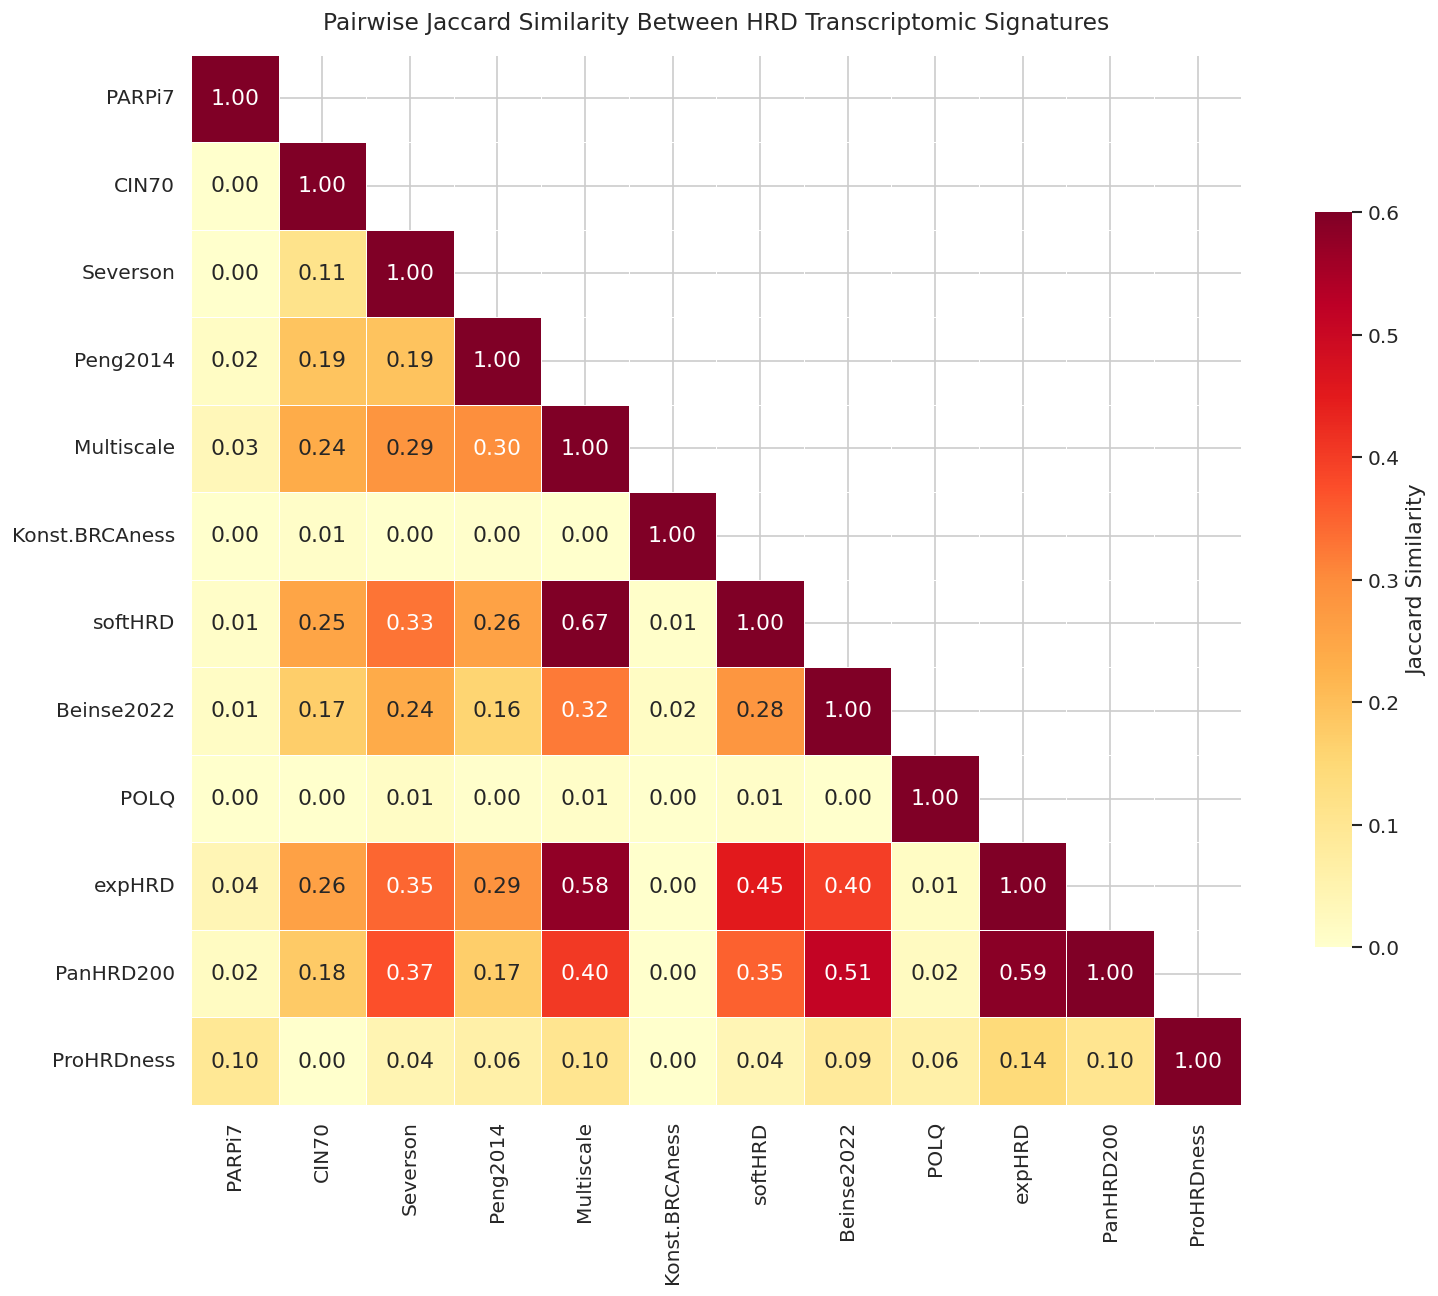

Saved jaccard_heatmap.png


In [7]:
# Heatmap of Jaccard similarities
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(jac_matrix, dtype=bool), k=1)

sns.heatmap(
    jac_df,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    vmin=0, vmax=0.6,
    linewidths=0.5,
    square=True,
    ax=ax,
    cbar_kws={'label': 'Jaccard Similarity', 'shrink': 0.7}
)
ax.set_title('Pairwise Jaccard Similarity Between HRD Transcriptomic Signatures', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'jaccard_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved jaccard_heatmap.png')

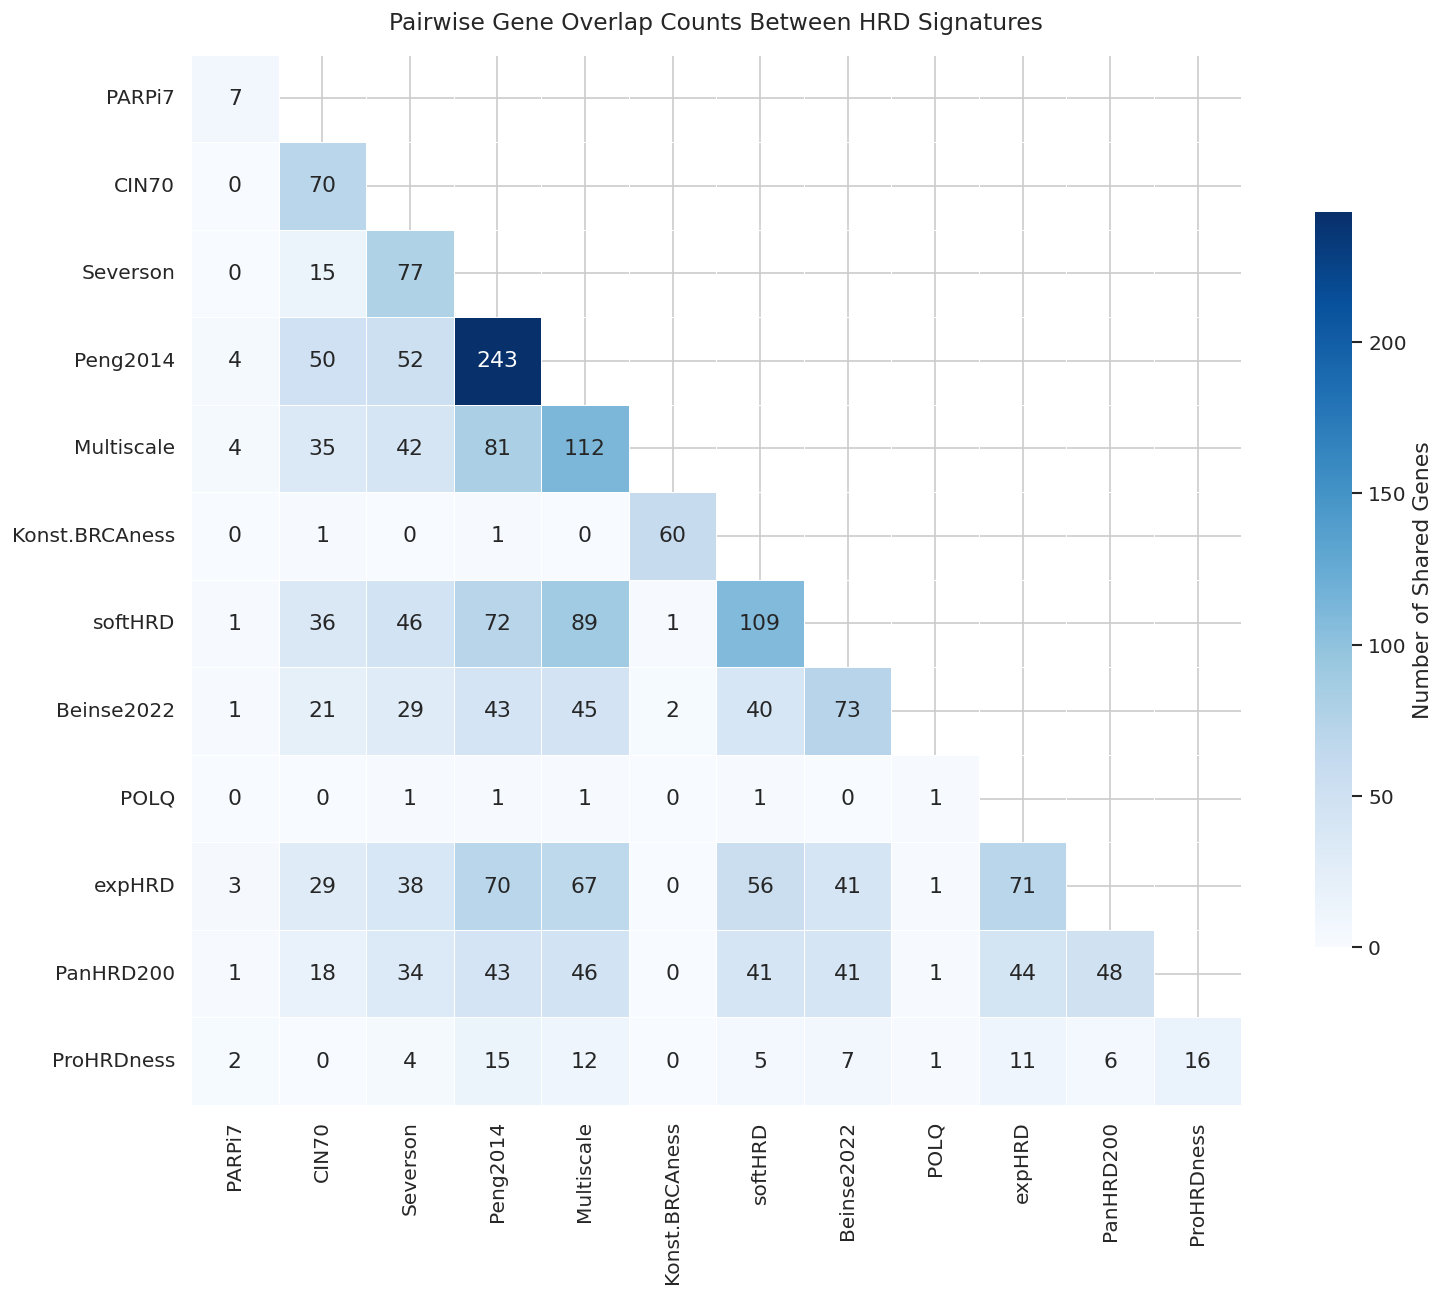

In [8]:
# Overlap counts matrix
overlap_matrix = np.zeros((n, n), dtype=int)
for i in range(n):
    for j in range(n):
        overlap_matrix[i, j] = len(set(sig_short[names[i]]) & set(sig_short[names[j]]))

overlap_df = pd.DataFrame(overlap_matrix, index=names, columns=names)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(overlap_matrix, dtype=bool), k=1)
sns.heatmap(
    overlap_df,
    mask=mask,
    annot=True, fmt='d',
    cmap='Blues',
    linewidths=0.5,
    square=True,
    ax=ax,
    cbar_kws={'label': 'Number of Shared Genes', 'shrink': 0.7}
)
ax.set_title('Pairwise Gene Overlap Counts Between HRD Signatures', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'overlap_counts_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Consensus HRD Genes (appearing in 3+ signatures)

In [9]:
# Count how many signatures each gene appears in
all_genes = []
for name, genes in sig_short.items():
    for g in genes:
        all_genes.append((g, name))

gene_sig_df = pd.DataFrame(all_genes, columns=['Gene', 'Signature'])
gene_counts = gene_sig_df.groupby('Gene')['Signature'].nunique().sort_values(ascending=False)

# Consensus genes: appear in >= 3 signatures
consensus_3 = gene_counts[gene_counts >= 3]
consensus_5 = gene_counts[gene_counts >= 5]
consensus_7 = gene_counts[gene_counts >= 7]

print(f'Genes in >= 3 signatures: {len(consensus_3)}')
print(f'Genes in >= 5 signatures: {len(consensus_5)}')
print(f'Genes in >= 7 signatures: {len(consensus_7)}')
print()
print('Top 40 consensus HRD genes (by signature count):')
consensus_3.head(40)

Genes in >= 3 signatures: 93
Genes in >= 5 signatures: 57
Genes in >= 7 signatures: 35

Top 40 consensus HRD genes (by signature count):


Gene
TTK         8
BRCA1       8
TPX2        8
PRC1        8
POLQ        8
RRM2        8
CDK1        8
TOP2A       8
CEP55       8
CHEK1       8
RAD51       8
FOXM1       8
AURKB       8
MELK        8
CCNA2       7
CENPF       7
CDC20       7
BUB1        7
PCNA        7
AURKA       7
ASPM        7
BLM         7
BIRC5       7
ANLN        7
MKI67       7
EXO1        7
MAD2L1      7
FANCA       7
NEK2        7
UBE2C       7
KIF11       7
MCM2        7
CENPA       7
CCNB1       7
PLK1        7
RAD51AP1    6
FANCD2      6
BRCA2       6
DEPDC1      6
MCM7        6
Name: Signature, dtype: int64

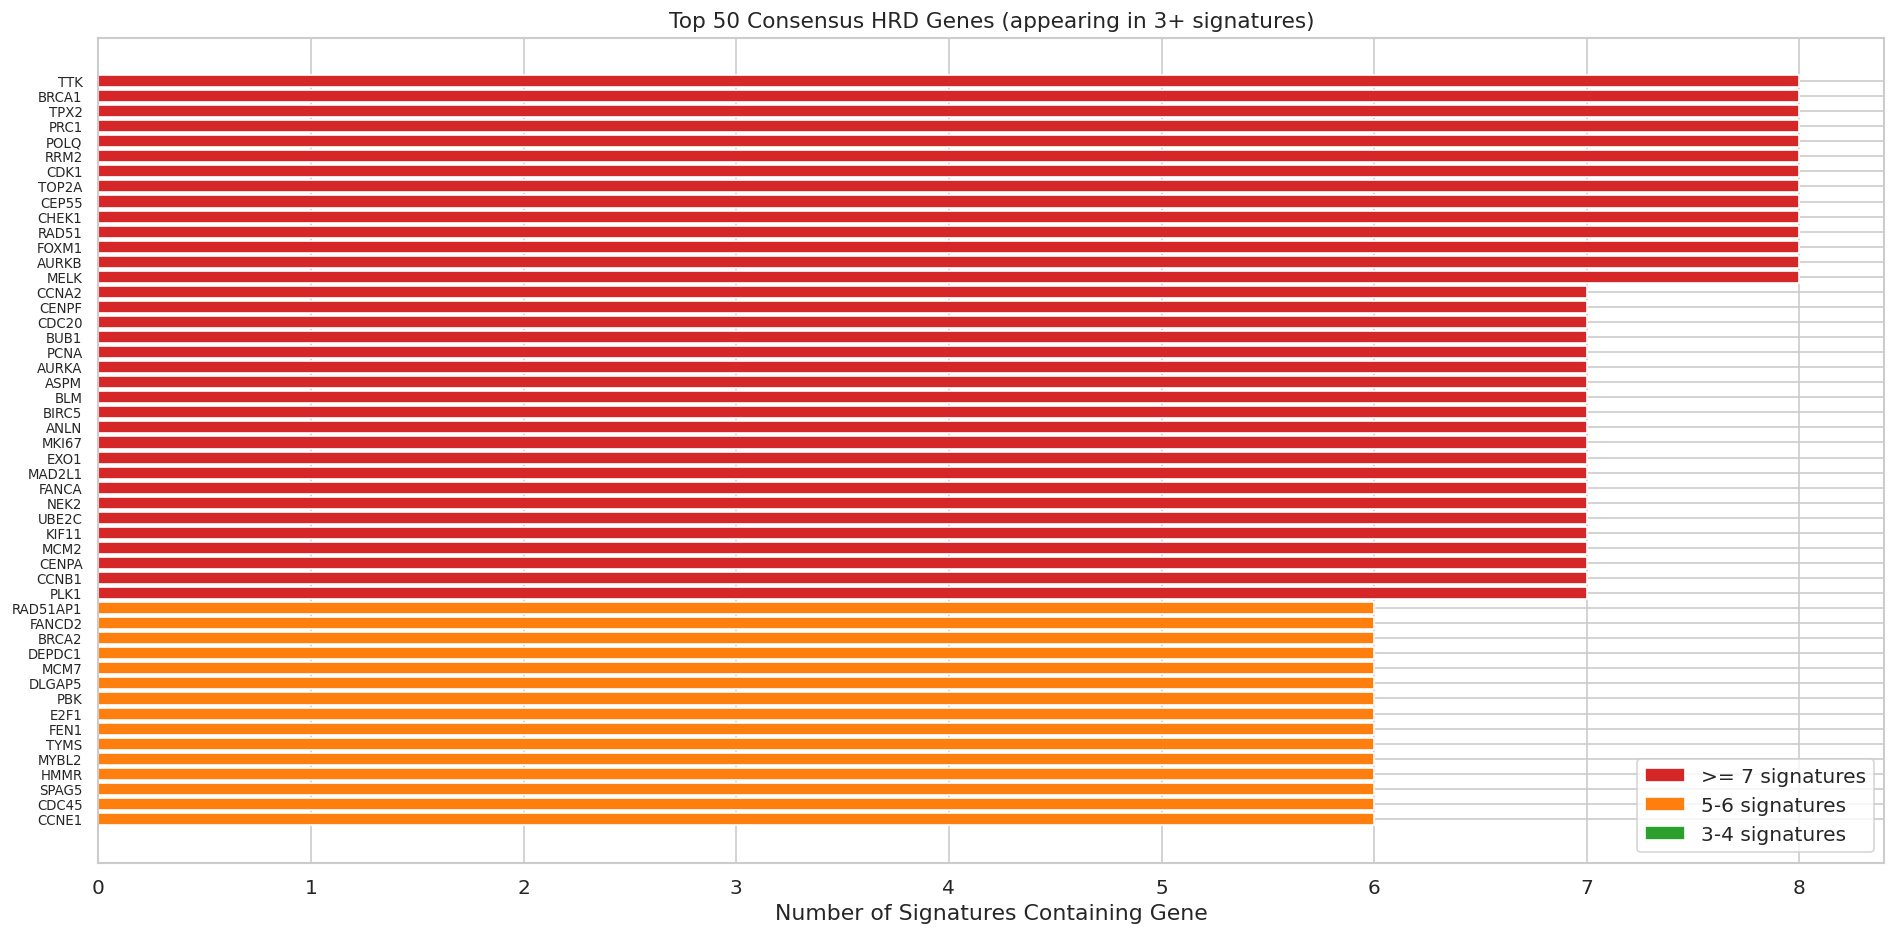

In [10]:
# Barplot of top consensus genes
top_genes = consensus_3.head(50)

fig, ax = plt.subplots(figsize=(16, 8))
colors = ['#d62728' if c >= 7 else '#ff7f0e' if c >= 5 else '#2ca02c' for c in top_genes.values]
ax.barh(range(len(top_genes)), top_genes.values, color=colors)
ax.set_yticks(range(len(top_genes)))
ax.set_yticklabels(top_genes.index, fontsize=8)
ax.set_xlabel('Number of Signatures Containing Gene')
ax.set_title('Top 50 Consensus HRD Genes (appearing in 3+ signatures)', fontsize=13)
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', label='>= 7 signatures'),
    Patch(facecolor='#ff7f0e', label='5-6 signatures'),
    Patch(facecolor='#2ca02c', label='3-4 signatures'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'consensus_genes_barplot.png'), dpi=150, bbox_inches='tight')
plt.show()

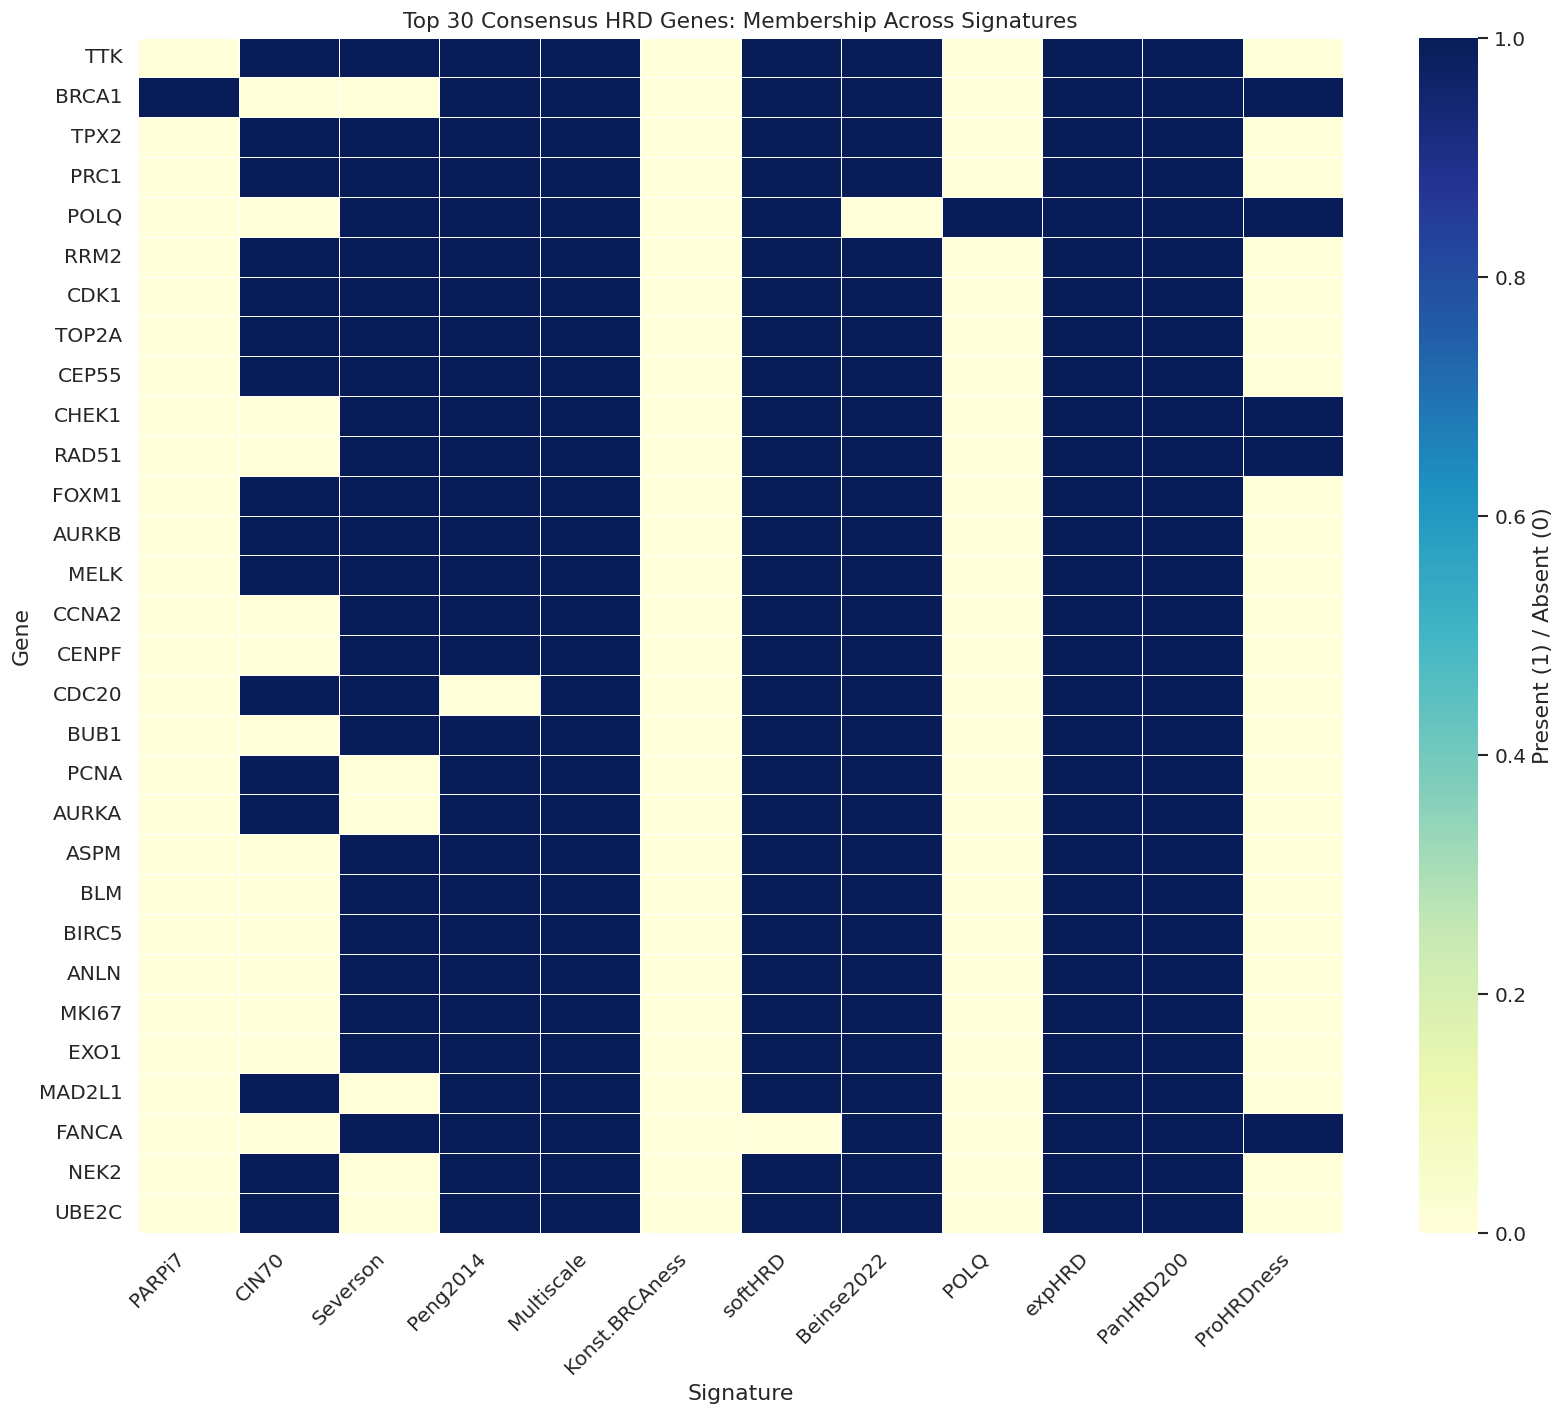

In [11]:
# Create a gene x signature membership matrix for the top consensus genes
consensus_genes_list = consensus_3.index.tolist()

membership = pd.DataFrame(0, index=consensus_genes_list, columns=list(sig_short.keys()))
for name, genes in sig_short.items():
    gene_set = set(genes)
    for g in consensus_genes_list:
        if g in gene_set:
            membership.loc[g, name] = 1

# Show top 30 genes
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    membership.iloc[:30],
    cmap='YlGnBu', linewidths=0.3,
    cbar_kws={'label': 'Present (1) / Absent (0)'},
    ax=ax
)
ax.set_title('Top 30 Consensus HRD Genes: Membership Across Signatures', fontsize=13)
ax.set_ylabel('Gene')
ax.set_xlabel('Signature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'gene_membership_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.3 UpSet Plot: Multi-way Signature Intersections

Shows which combinations of signatures share genes.

/home/dani/miniconda3/envs/ML/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/dani/miniconda3/envs/ML/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].f

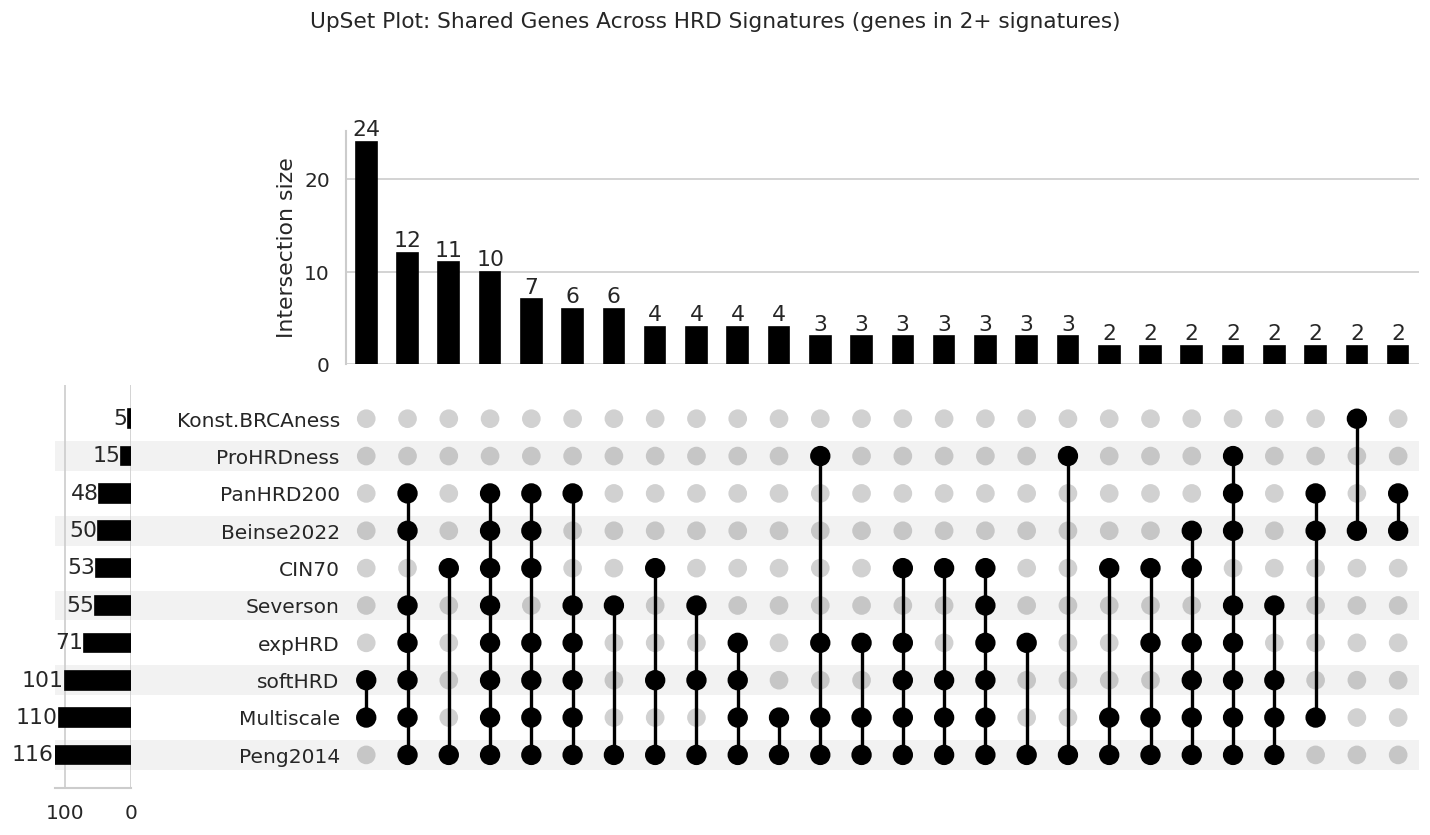

In [12]:
# Build UpSet data: for each gene, record which signatures it belongs to
# Focus on the larger signatures (exclude POLQ single-gene and small prostate set)
upset_sigs = {k: v for k, v in sig_short.items() if len(v) >= 10}

gene_to_sigs = {}
for name, genes in upset_sigs.items():
    for g in genes:
        if g not in gene_to_sigs:
            gene_to_sigs[g] = set()
        gene_to_sigs[g].add(name)

# Only include genes in 2+ signatures for the UpSet plot
memberships_list = []
for gene, sigs in gene_to_sigs.items():
    if len(sigs) >= 2:
        memberships_list.append(tuple(sorted(sigs)))

if len(memberships_list) > 0:
    # Count occurrences of each membership pattern
    from collections import Counter
    membership_counts = Counter(memberships_list)
    
    upset_data = from_memberships(
        membership_counts.keys(),
        data=list(membership_counts.values())
    )
    
    fig = plt.figure(figsize=(18, 8))
    upset = UpSet(upset_data, min_subset_size=2, show_counts=True, sort_by='cardinality',
                  subset_size='sum')
    upset.plot(fig=fig)
    fig.suptitle('UpSet Plot: Shared Genes Across HRD Signatures (genes in 2+ signatures)', y=1.02, fontsize=13)
    plt.savefig(os.path.join(out_dir, 'upset_plot.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Not enough multi-membership genes for UpSet plot')

---
## Part 3: What Each Signature Actually Captures

### 3.1 Manual Biological Process Categorization

For each signature, we classify genes into biological categories to understand
**what aspect of HRD biology** the signature is picking up.

In [13]:
# Define biological process categories with representative genes
bio_categories = {
    'HR/DNA Repair': {'BRCA1','BRCA2','RAD51','RAD51AP1','RAD51B','RAD51C','RAD51D',
                      'EXO1','BLM','FANCA','FANCD2','FANCI','FANCC','FANCG','FANCL','FANCM',
                      'NBN','MRE11','RAD50','PALB2','XRCC2','XRCC3','ATR','ATM','ATRIP',
                      'CHEK1','CHEK2','TOPBP1','CLSPN','CLASPIN','TIMELESS','TIPIN',
                      'WRN','RECQL4','RECQL5','GEN1','MUS81','EME1','SLX4',
                      'APEX1','PMS1','PMS2','MSH2','MSH6','MLH1','TDG','XPA',
                      'H2AX','H2AFX','NEIL3','UNG','WRAP53','MAPKAPK2','POLQ',
                      'DNA2','EXO5','ERCC6L','FEN1','RNASEH2A'},
    'Cell Cycle': {'CDK1','CDK2','CDK12','CCNA2','CCNB1','CCNB2','CCNE1','CCND1',
                   'CDC20','CDC25A','CDC25C','CDC45','CDC6','CDT1',
                   'PLK1','PLK4','AURKA','AURKB','BUB1','BUB1B','MAD2L1','MAD1L1',
                   'TTK','ESPL1','CDCA2','CDCA3','CDCA5','CDCA8',
                   'CDKN3','CKS1B','CKS2','RB1','E2F1','E2F8','MYBL2',
                   'GADD45A','GADD45G','SESN1','SESN2','DDIT3','MKI67'},
    'Replication': {'MCM2','MCM3','MCM4','MCM5','MCM6','MCM7','MCM10','MCMBP',
                    'ORC1','ORC6','PCNA','RPA1','RPA2','RPA3',
                    'RFC1','RFC2','RFC3','RFC4','RFC5','LIG1',
                    'POLE','POLE2','POLD1','POLD2','PRIM1','PRIM2','POLA1','POLG',
                    'TOP2A','DSCC1','ATAD5','TICRR',
                    'GINS1','DTL'},
    'Chromosomal Instability\n/ Mitosis': {'CENPA','CENPE','CENPF','CENPK','CENPL','CENPU',
                    'KIF11','KIF14','KIF15','KIF2C','KIF4A','KIF20A','KIF23','KIFC1',
                    'NDC80','NUF2','SPC25','SKA1','SKA2','SKA3',
                    'TPX2','PRC1','ANLN','ECT2','CEP55','CEP128','CEP250',
                    'BIRC5','ASPM','HMMR','SPAG5','NEK2','PBK','MELK',
                    'UBE2C','PTTG1','DEPDC1','DEPDC1B','DLGAP5','FOXM1',
                    'NCAPH','NCAPG','NCAPG2','SMC2','SMC4','RAD21','SMC1A',
                    'ZWINT','ZWILCH','ZW10','SGOL1','SGOL2','TACC3',
                    'RACGAP1','KNL1','MIS18A','INCENP','CIT','SHCBP1',
                    'HAUS6','TUBG1','TUBB','TUBA1B','TUBA1C','TUBB4B',
                    'H2AZ1','STAG1','CKAP5','NUP205'},
    'Nucleotide Metabolism': {'RRM1','RRM2','TYMS','DHFR','TK1','GMPS','CTPS1',
                              'UMPS','CAD','SHMT2','MTHFD1','MTHFD2','GGH','SLC7A5'},
    'Epigenetic Regulation': {'EZH2','UHRF1','DNMT1','SUV39H1','HMGA1','HMGA2',
                              'HDAC1','CHAF1A','CHAF1B','ASF1B','NAP1L1','RBBP4',
                              'ACTL6A','ATAD2','DKC1','HMGN2'},
    'Immune / Microenvironment': {'GBP1','CCL4','TNF','HLA-A','HLA-B','BST2','SRGN',
                                   'NMI','PRAME','RGS1','WAS','CD1D','PSTPIP1',
                                   'SYK','CD109','MFGE8'},
    'Hormone Receptor / Signaling': {'ESR1','PGR','GATA3','FOXA1','TFF1','TFF3',
                                      'GRB7','ERBB2','HIF1A'},
    'Stromal / EMT': {'VIM','FN1','COL1A1','COL3A1','SPARC','POSTN','MMP2','MMP7',
                       'ACTA2','TAGLN','DCN','LUM','BGN','THBS2','FAP','PDGFRB',
                       'NOTCH3','THY1','CAV1','CDH11','SNAI2','ZEB1','TWIST1','CD44',
                       'CYR61','VEGFA','ENG','SEMA3F','CLDN1'},
    'Metabolism / Other': {'LDHA','ECHS1','DHCR7','SQLE','FDFT1','ACAT2','ALDH1B1',
                            'MTCH2','NDUFAB1','MGST2','MGST3',
                            'RPTOR','CREBRF','MDM2','TP53','BAD','SNCA',
                            'WFDC2','ROS1','MADCAM1','ALPP','DAD1','RCN2',
                            'SERPINF2','IDUA','VTN','MTAP','GUCY1B3',
                            'ELAVL1','HDGF','NXT1','LSM4','SRSF2',
                            'RAN','SKP1','PPP1CC','USP9X','GNAI3','LGMN',
                            'SH3BGRL','PDIA4','TM9SF1','CCDC93','PCTP','SEH1L',
                            'SAT1','GFI1','S100A10','UNC119B','PDCD2L',
                            'CMAS','NEMP1','OIP5','CCT5'},
}

# For each signature, compute fraction of genes in each category
category_fractions = {}
for sig_name, sig_genes in sig_short.items():
    gene_set = set(sig_genes)
    fracs = {}
    categorized = set()
    for cat, cat_genes in bio_categories.items():
        overlap = gene_set & cat_genes
        fracs[cat] = len(overlap) / len(gene_set) if len(gene_set) > 0 else 0
        categorized |= overlap
    fracs['Uncategorized'] = len(gene_set - categorized) / len(gene_set) if len(gene_set) > 0 else 0
    category_fractions[sig_name] = fracs

cat_df = pd.DataFrame(category_fractions).T
cat_df = cat_df.round(3)
print('Fraction of each signature in each biological category:')
cat_df

Fraction of each signature in each biological category:


,HR/DNA Repair,Cell Cycle,Replication,Chromosomal Instability\n/ Mitosis,Nucleotide Metabolism,Epigenetic Regulation,Immune / Microenvironment,Hormone Receptor / Signaling,Stromal / EMT,Metabolism / Other,Uncategorized
PARPi7,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
CIN70,0.086,0.200,0.086,0.300,0.043,0.071,0.000,0.000,0.000,0.186,0.029
Severson,0.104,0.195,0.039,0.377,0.026,0.000,0.000,0.026,0.013,0.000,0.221
Peng2014,0.222,0.156,0.128,0.255,0.058,0.045,0.000,0.000,0.000,0.016,0.119
Multiscale,0.179,0.205,0.089,0.205,0.036,0.036,0.027,0.036,0.000,0.054,0.134
Konst.BRCAness,0.033,0.000,0.000,0.033,0.017,0.033,0.217,0.000,0.117,0.533,0.017
softHRD,0.101,0.174,0.064,0.284,0.028,0.037,0.028,0.018,0.009,0.055,0.202
Beinse2022,0.137,0.164,0.068,0.205,0.027,0.000,0.000,0.082,0.315,0.000,0.000
POLQ,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
expHRD,0.296,0.239,0.070,0.310,0.028,0.056,0.000,0.000,0.000,0.000,0.000


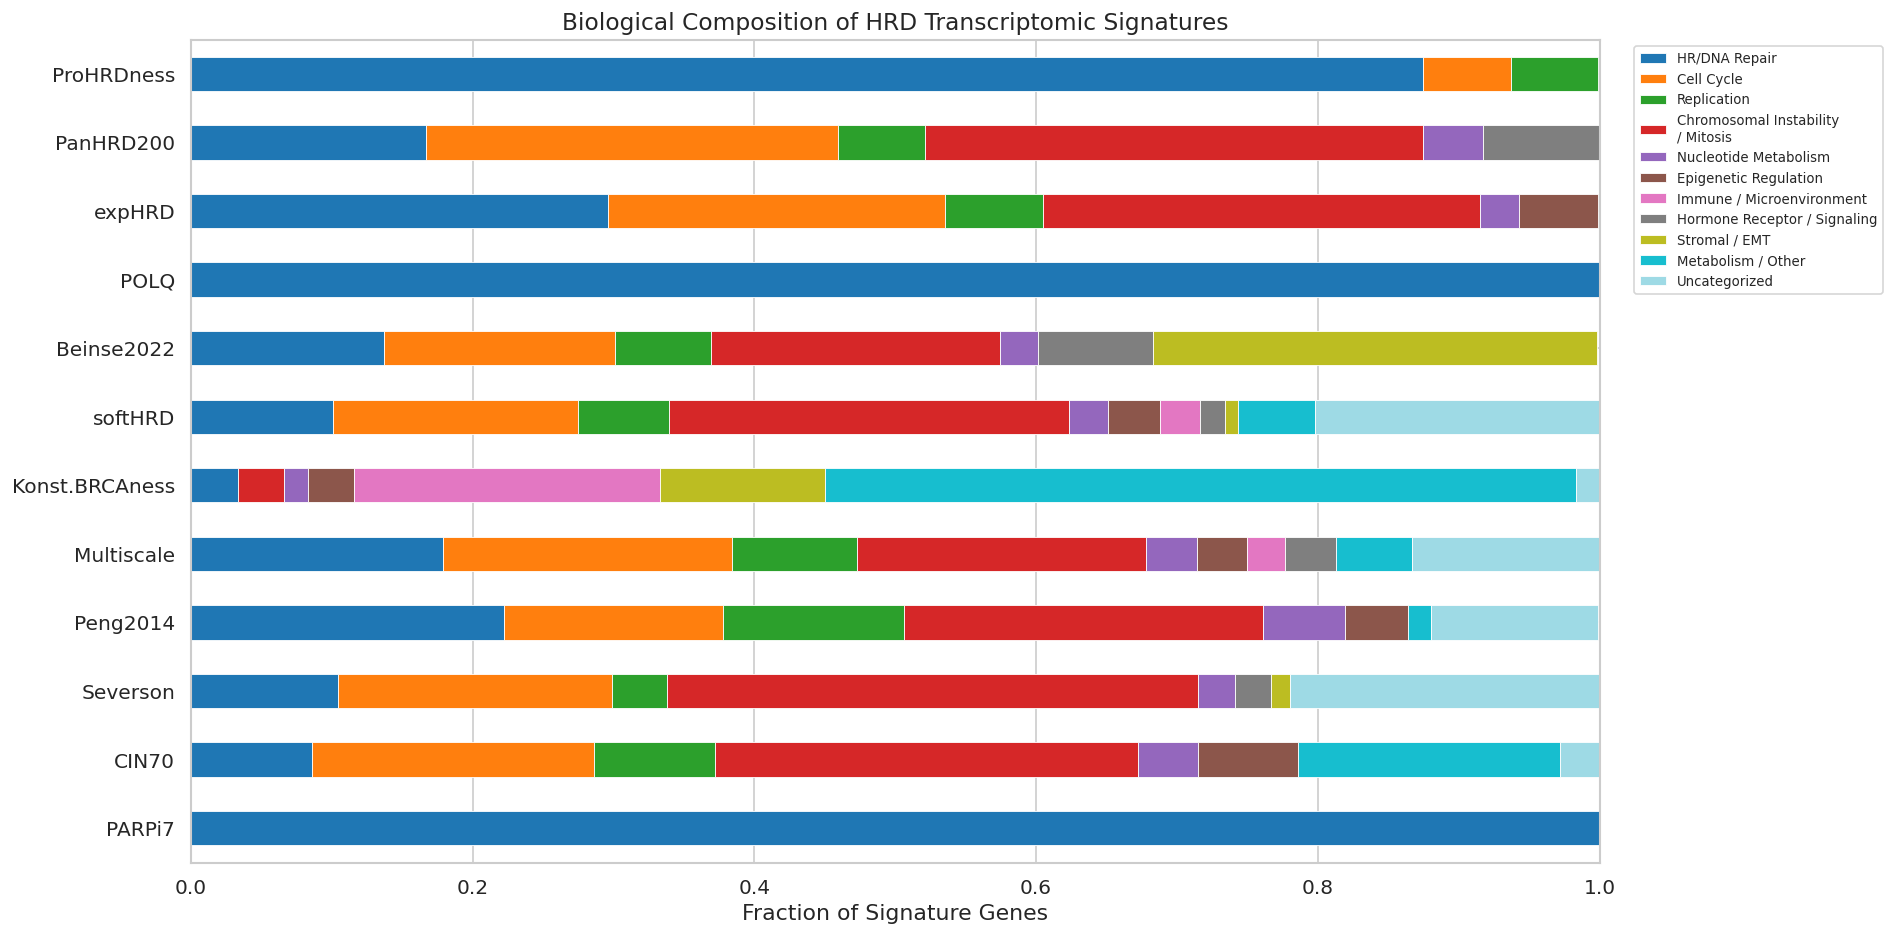

In [14]:
# Stacked bar chart of biological composition
fig, ax = plt.subplots(figsize=(16, 8))

# Use a colorful palette
colors = plt.cm.tab20(np.linspace(0, 1, len(cat_df.columns)))

cat_df_plot = cat_df.copy()
cat_df_plot.plot(
    kind='barh', stacked=True, ax=ax,
    color=colors, edgecolor='white', linewidth=0.5
)

ax.set_xlabel('Fraction of Signature Genes')
ax.set_title('Biological Composition of HRD Transcriptomic Signatures', fontsize=14)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'biological_composition.png'), dpi=150, bbox_inches='tight')
plt.show()

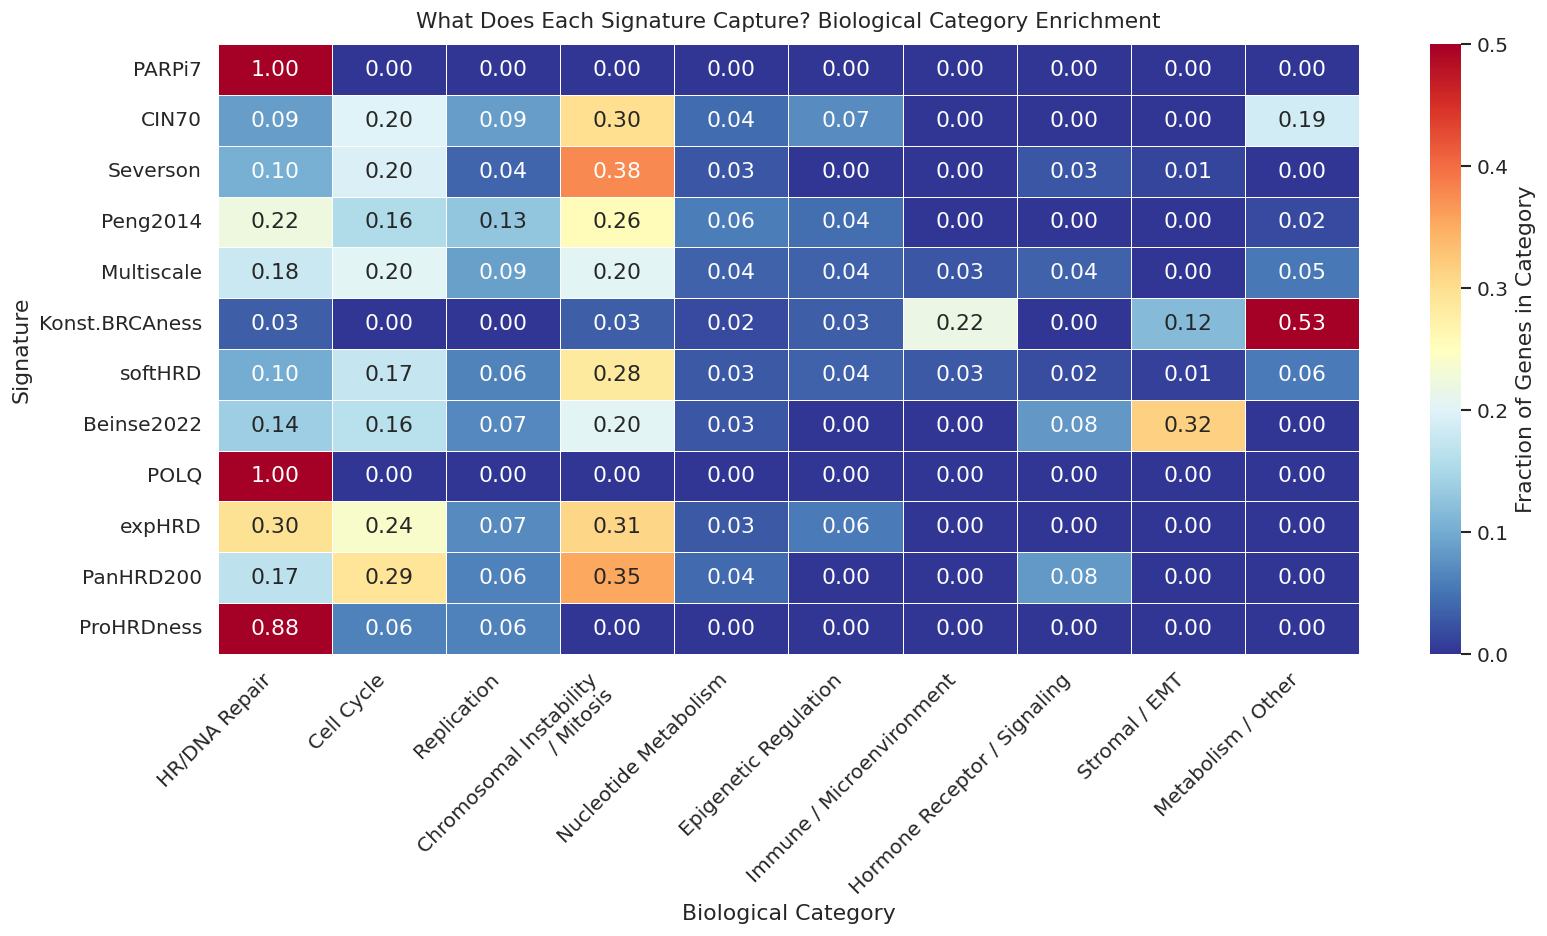

In [15]:
# Heatmap of biological category enrichment per signature
fig, ax = plt.subplots(figsize=(14, 8))

# Drop 'Uncategorized' for cleaner view
cat_heatmap = cat_df.drop(columns=['Uncategorized'], errors='ignore')

sns.heatmap(
    cat_heatmap,
    annot=True, fmt='.2f',
    cmap='RdYlBu_r',
    vmin=0, vmax=0.5,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Fraction of Genes in Category'}
)
ax.set_title('What Does Each Signature Capture? Biological Category Enrichment', fontsize=13, pad=10)
ax.set_ylabel('Signature')
ax.set_xlabel('Biological Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'category_enrichment_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Key Observations

Based on the biological composition analysis, we can now explain **why different HRD signatures
often disagree**:

1. **CIN70** is primarily a chromosomal instability / mitosis signature with minimal direct
   HR repair content. It detects genomic instability consequences, not the repair defect itself.

2. **Konstantinopoulos BRCAness** is heavily weighted toward immune/microenvironment and
   stromal genes, reflecting the tumor microenvironment differences in BRCA-mutant ovarian
   cancers rather than the intrinsic repair defect.

3. **Peng 2014** and **Multiscale HRD** both capture a broad mix of HR repair + cell cycle +
   replication + mitosis genes, making them more directly reflective of the HRD phenotype.

4. **Severson BRCA1ness** is enriched for cell cycle and mitosis genes with moderate HR repair
   content, reflecting the high-proliferation phenotype of BRCA1-deficient TNBCs.

5. **PARPi7** is a focused DNA repair signature (7 genes) that directly interrogates repair
   pathway function but may miss broader transcriptomic changes.

6. **POLQ** captures a single mechanistic link: HR-deficient cells upregulate POLQ for
   alternative end-joining, making it very specific but low-sensitivity.

7. **softHRD** and **Multiscale** share the most genes (as expected, being from the same lab),
   with a balanced mix across categories.

8. **Beinse 2022** pan-gynecological signature uniquely captures stromal/EMT genes alongside
   repair genes, reflecting cross-cancer heterogeneity.

**Implication for v2:** A robust HRD classifier should capture genes from multiple categories
(HR repair, cell cycle, CIN, replication) rather than relying on just one facet.

### 3.3 Consensus Core vs. Unique Genes

In [16]:
# Categorize consensus genes (>= 5 signatures)
consensus_set = set(consensus_5.index)

consensus_cats = {}
for cat, cat_genes in bio_categories.items():
    overlap = consensus_set & cat_genes
    if len(overlap) > 0:
        consensus_cats[cat] = sorted(overlap)

print('CONSENSUS HRD GENES (>= 5 signatures) by biological category:')
print('=' * 70)
for cat, genes in sorted(consensus_cats.items(), key=lambda x: -len(x[1])):
    print(f'\n{cat} ({len(genes)} genes):')
    print(f'  {", ".join(genes)}')

CONSENSUS HRD GENES (>= 5 signatures) by biological category:

Chromosomal Instability
/ Mitosis (21 genes):
  ANLN, ASPM, BIRC5, CENPA, CENPF, CEP55, DEPDC1, DLGAP5, FOXM1, HMMR, KIF11, KIF2C, MELK, NCAPG2, NCAPH, NEK2, PBK, PRC1, SPAG5, TPX2, UBE2C

Cell Cycle (16 genes):
  AURKA, AURKB, BUB1, CCNA2, CCNB1, CCNE1, CDC20, CDC25C, CDC45, CDK1, E2F1, MAD2L1, MKI67, MYBL2, PLK1, TTK

HR/DNA Repair (12 genes):
  ATR, BLM, BRCA1, BRCA2, CHEK1, EXO1, FANCA, FANCD2, FEN1, POLQ, RAD51, RAD51AP1

Replication (5 genes):
  MCM2, MCM7, PCNA, RFC4, TOP2A

Nucleotide Metabolism (2 genes):
  RRM2, TYMS

Epigenetic Regulation (1 genes):
  EZH2


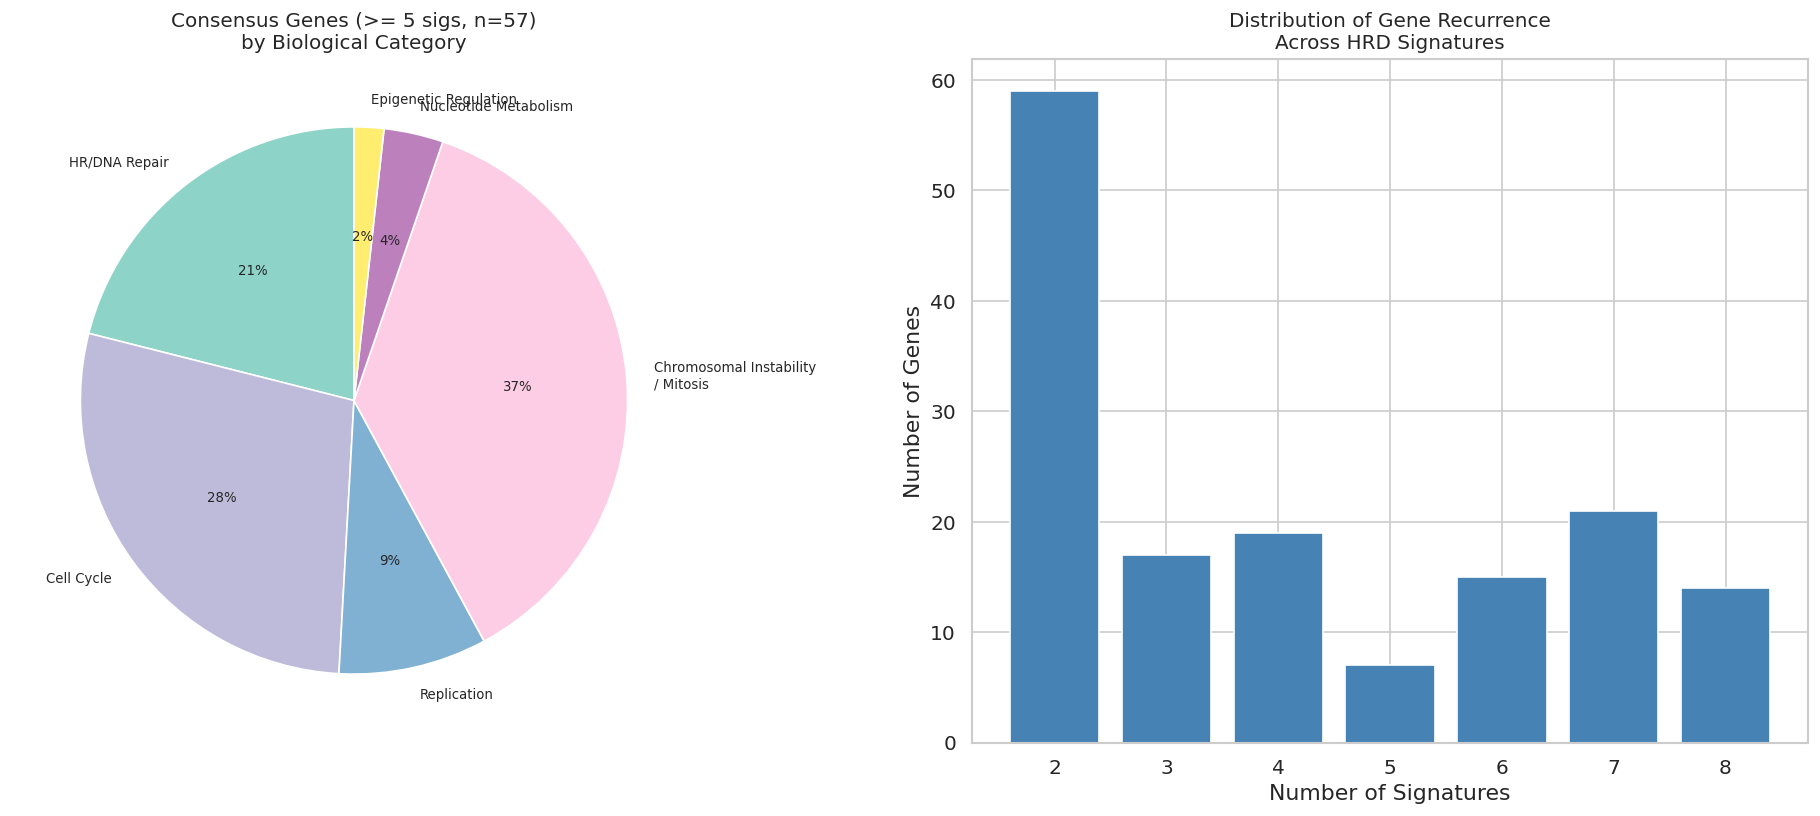

In [17]:
# Pie chart: consensus gene biological categories
cat_sizes = {cat: len(genes) for cat, genes in consensus_cats.items()}
uncategorized = len(consensus_set - set().union(*bio_categories.values()))
if uncategorized > 0:
    cat_sizes['Uncategorized'] = uncategorized

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pie chart
labels = list(cat_sizes.keys())
sizes = list(cat_sizes.values())
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(labels)))

axes[0].pie(sizes, labels=labels, autopct='%1.0f%%', colors=colors_pie, startangle=90,
            textprops={'fontsize': 8})
axes[0].set_title(f'Consensus Genes (>= 5 sigs, n={len(consensus_set)})\nby Biological Category', fontsize=12)

# Distribution of how many signatures each gene appears in
sig_count_dist = gene_counts[gene_counts >= 2].value_counts().sort_index()
axes[1].bar(sig_count_dist.index, sig_count_dist.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Number of Signatures')
axes[1].set_ylabel('Number of Genes')
axes[1].set_title('Distribution of Gene Recurrence\nAcross HRD Signatures', fontsize=12)
axes[1].set_xticks(range(2, sig_count_dist.index.max() + 1))

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'consensus_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Signature Clustering (Hierarchical)

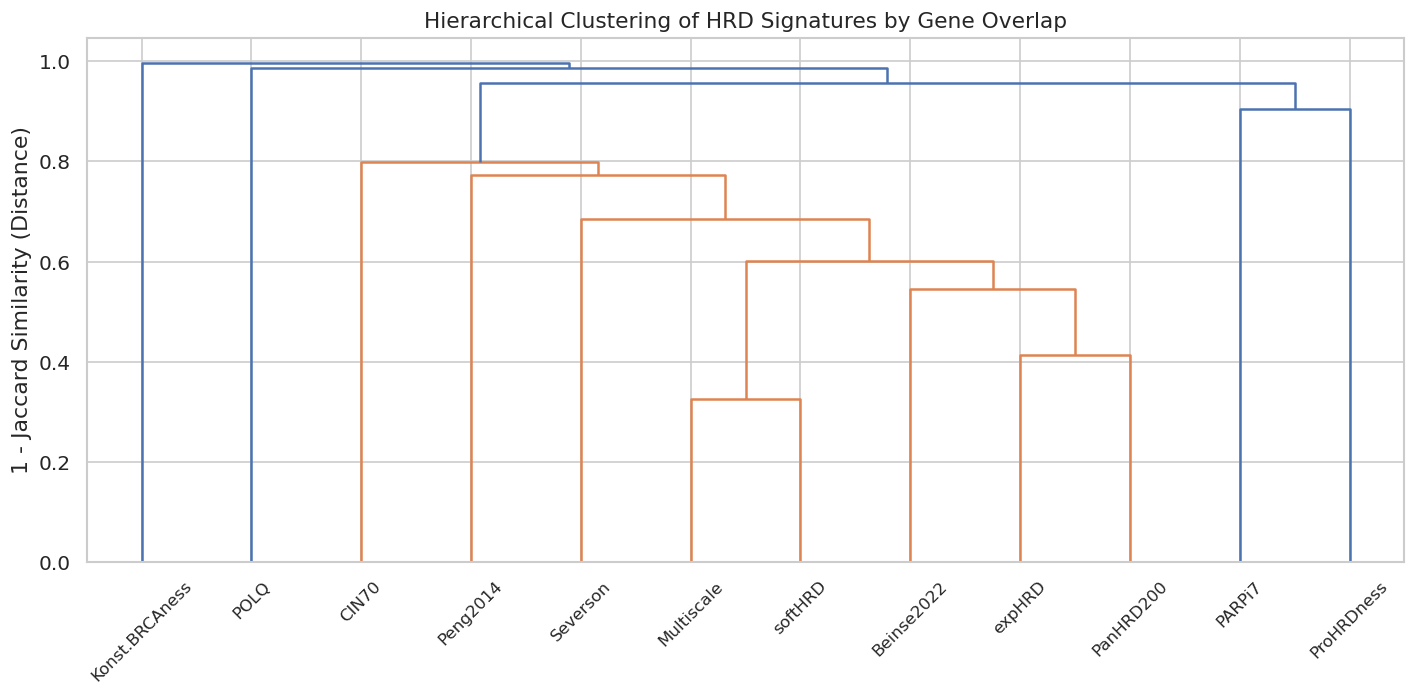

In [18]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Convert Jaccard similarity to distance
jac_dist = 1 - jac_matrix
np.fill_diagonal(jac_dist, 0)

# Linkage
condensed = squareform(jac_dist)
Z = linkage(condensed, method='average')

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    Z, labels=names, ax=ax,
    leaf_rotation=45, leaf_font_size=10,
    color_threshold=0.85
)
ax.set_ylabel('1 - Jaccard Similarity (Distance)')
ax.set_title('Hierarchical Clustering of HRD Signatures by Gene Overlap', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'signature_dendrogram.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Summary Table: What Each Signature Captures

In [19]:
# Summary interpretation
interpretation = pd.DataFrame([
    {'Signature': 'PARPi7', 'Primary_biology': 'DNA Damage Response',
     'What_it_captures': 'Direct HR repair gene expression (BRCA1, CHEK2, MRE11, etc.)',
     'Strength': 'Directly assesses repair capacity',
     'Limitation': 'Only 7 genes; misses broader transcriptomic changes'},
    {'Signature': 'CIN70', 'Primary_biology': 'Chromosomal Instability',
     'What_it_captures': 'Mitotic fidelity and chromosome segregation programs',
     'Strength': 'Detects genomic instability consequences',
     'Limitation': 'Not specific to HRD; captures general proliferation/CIN'},
    {'Signature': 'Severson BRCA1ness', 'Primary_biology': 'Cell Cycle + Mitosis',
     'What_it_captures': 'BRCA1-like proliferation phenotype in TNBC',
     'Strength': 'Validated against PARPi response (I-SPY 2)',
     'Limitation': 'TNBC-specific; may not transfer to HR+ or non-breast'},
    {'Signature': 'Peng 2014', 'Primary_biology': 'HR Repair + Cell Cycle + Replication',
     'What_it_captures': 'Comprehensive HRD cell-intrinsic program from knockdown models',
     'Strength': 'Mechanistically derived (siRNA knockdown)',
     'Limitation': 'Cell line-derived; may not capture TME effects'},
    {'Signature': 'Multiscale HRD', 'Primary_biology': 'HR Repair + Cell Cycle + Signaling',
     'What_it_captures': 'Deconvoluted tumor-cell HRD phenotype with BRCA-defect subtyping',
     'Strength': 'Expression deconvolution; multinomial classification',
     'Limitation': 'Breast-cancer trained; requires deconvolution reference'},
    {'Signature': 'Konst. BRCAness', 'Primary_biology': 'Immune/Stromal + DNA Repair',
     'What_it_captures': 'BRCA-like microenvironment phenotype in ovarian cancer',
     'Strength': 'Captures TME differences; validated for platinum response',
     'Limitation': 'Ovarian-specific; heavy TME component may confound'},
    {'Signature': 'softHRD', 'Primary_biology': 'HR Repair + Cell Cycle + CIN',
     'What_it_captures': 'Balanced HRD phenotype using soft-label regression',
     'Strength': 'Soft labels reduce ambiguity near thresholds',
     'Limitation': 'Still trained on HRD-sum threshold; single cohort'},
    {'Signature': 'Beinse 2022', 'Primary_biology': 'HR Repair + Stromal + EMT',
     'What_it_captures': 'Pan-gynecological HRD including microenvironment changes',
     'Strength': 'Cross-cancer; high AUC (0.96)',
     'Limitation': 'Stromal genes may reflect composition not HRD per se'},
    {'Signature': 'POLQ', 'Primary_biology': 'Alternative End-Joining',
     'What_it_captures': 'Compensatory repair pathway upregulation in HR-deficient cells',
     'Strength': 'Mechanistically clear; therapeutic target',
     'Limitation': 'Single gene; limited sensitivity'},
    {'Signature': 'expHRD', 'Primary_biology': 'HR Repair + Cell Cycle + Epigenetic',
     'What_it_captures': 'Individualized scarHRD score prediction from transcriptome',
     'Strength': 'N-of-1 scoring; pan-cancer potential',
     'Limitation': 'Trained on OV; transfer to other cancers uncertain'},
    {'Signature': 'Pan HRD200', 'Primary_biology': 'HR Repair + Cell Cycle',
     'What_it_captures': 'TNBC-specific HRD classification from WGS-defined labels',
     'Strength': 'WGS-based labels; validated in TCGA/METABRIC/ICGC',
     'Limitation': 'TNBC-specific; relies on WGS for label generation'},
    {'Signature': 'Prostate HRDness', 'Primary_biology': 'HR Repair',
     'What_it_captures': 'Prostate-specific HRD classification via gene pair ordering',
     'Strength': 'Tissue-specific; robust to batch effects (REO-based)',
     'Limitation': 'Prostate-only; gene pair approach limits to 32 genes'},
])

interpretation = interpretation.set_index('Signature')
interpretation

,Primary_biology,What_it_captures,Strength,Limitation
Signature,,,,
PARPi7,DNA Damage Response,"Direct HR repair gene expression (BRCA1, CHEK2...",Directly assesses repair capacity,Only 7 genes; misses broader transcriptomic ch...
CIN70,Chromosomal Instability,Mitotic fidelity and chromosome segregation pr...,Detects genomic instability consequences,Not specific to HRD; captures general prolifer...
Severson BRCA1ness,Cell Cycle + Mitosis,BRCA1-like proliferation phenotype in TNBC,Validated against PARPi response (I-SPY 2),TNBC-specific; may not transfer to HR+ or non-...
Peng 2014,HR Repair + Cell Cycle + Replication,Comprehensive HRD cell-intrinsic program from ...,Mechanistically derived (siRNA knockdown),Cell line-derived; may not capture TME effects
Multiscale HRD,HR Repair + Cell Cycle + Signaling,Deconvoluted tumor-cell HRD phenotype with BRC...,Expression deconvolution; multinomial classifi...,Breast-cancer trained; requires deconvolution ...
Konst. BRCAness,Immune/Stromal + DNA Repair,BRCA-like microenvironment phenotype in ovaria...,Captures TME differences; validated for platin...,Ovarian-specific; heavy TME component may conf...
softHRD,HR Repair + Cell Cycle + CIN,Balanced HRD phenotype using soft-label regres...,Soft labels reduce ambiguity near thresholds,Still trained on HRD-sum threshold; single cohort
Beinse 2022,HR Repair + Stromal + EMT,Pan-gynecological HRD including microenvironme...,Cross-cancer; high AUC (0.96),Stromal genes may reflect composition not HRD ...
POLQ,Alternative End-Joining,Compensatory repair pathway upregulation in HR...,Mechanistically clear; therapeutic target,Single gene; limited sensitivity


---
## Summary & Conclusions

### Key Findings:

1. **No two signatures are identical** — even for the same biological question (is this tumor HR-deficient?), different groups capture different facets of the phenotype.

2. **Consensus core genes** (appearing in 5+ signatures) are predominantly in:
   - **DNA damage response / HR repair** (BRCA1, RAD51, CHEK1, EXO1, BLM, FANCA, etc.)
   - **Cell cycle** (CDK1, CCNA2, CCNB1, PLK1, AURKA, BUB1, etc.)
   - **Chromosomal instability / mitosis** (CENPA, KIF11, TPX2, BIRC5, etc.)

3. **Signatures disagree because they capture different biology:**
   - CIN70 → chromosomal instability
   - Konstantinopoulos → immune/microenvironment
   - Peng/Multiscale/softHRD → balanced HR + cell cycle + replication
   - POLQ → alternative repair pathway

4. **For v2 model development**, we should:
   - Include consensus HRD genes as anchors
   - Capture biology from multiple categories (not just cell cycle)
   - Use expression deconvolution to separate tumor-intrinsic from TME signals
   - Validate against multiple orthogonal labels (not just GIS score)
   - Consider POLQ as a complementary single-gene marker

In [20]:
# Save all gene lists as CSV for downstream use
gene_lists_rows = []
for sig_name, genes in sig_short.items():
    for g in genes:
        gene_lists_rows.append({'Signature': sig_name, 'Gene': g})

gene_lists_df = pd.DataFrame(gene_lists_rows)
gene_lists_df.to_csv(os.path.join(out_dir, 'all_signature_gene_lists.csv'), index=False)

# Save consensus genes
consensus_df = pd.DataFrame({
    'Gene': consensus_3.index,
    'N_signatures': consensus_3.values
})
consensus_df.to_csv(os.path.join(out_dir, 'consensus_hrd_genes.csv'), index=False)

# Save Jaccard matrix
jac_df.to_csv(os.path.join(out_dir, 'jaccard_similarity_matrix.csv'))

print('Saved output files:')
print('  - hrd_signature_catalog.csv')
print('  - all_signature_gene_lists.csv')
print('  - consensus_hrd_genes.csv')
print('  - jaccard_similarity_matrix.csv')
print('  - jaccard_heatmap.png')
print('  - overlap_counts_heatmap.png')
print('  - consensus_genes_barplot.png')
print('  - gene_membership_heatmap.png')
print('  - upset_plot.png')
print('  - biological_composition.png')
print('  - category_enrichment_heatmap.png')
print('  - consensus_analysis.png')
print('  - signature_dendrogram.png')
print()
print('Analysis complete.')

Saved output files:
  - hrd_signature_catalog.csv
  - all_signature_gene_lists.csv
  - consensus_hrd_genes.csv
  - jaccard_similarity_matrix.csv
  - jaccard_heatmap.png
  - overlap_counts_heatmap.png
  - consensus_genes_barplot.png
  - gene_membership_heatmap.png
  - upset_plot.png
  - biological_composition.png
  - category_enrichment_heatmap.png
  - consensus_analysis.png
  - signature_dendrogram.png

Analysis complete.
